# Multi-Sample Study: MCMC vs SBI

Evaluate inference robustness by running MCMC and SBI on 500 observations (different noise realizations) with the same true parameters per scenario. This notebook produces the main results for the paper (Figs. 2-5).

**Approach:**
1. Load cached observations from `data/observations.npz`
2. Train SBI (SNPE with Neural Spline Flows) on 50,000 simulations
3. Run SBI inference on all 500 observations per scenario
4. Load pre-computed MCMC posteriors from `results/mcmc_posteriors.npz`
5. Compare via Wasserstein distance, CRPS, coverage, and posterior statistics

In [1]:
import numpyro
numpyro.set_host_device_count(4)

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import time
import json

import jax
import jax.numpy as jnp
from numpyro.infer import Predictive
from numpyro import handlers

import torch
from sbi.utils import process_prior, BoxUniform
from sbi.inference import SNPE
from sbi.neural_nets import posterior_nn
from torch.distributions import MultivariateNormal

import hx_models.heat_exchanger as hx
from hx_models.inference import (
    MODE_NAMES, K_CATEGORICAL4,
    PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_F_STD,
    PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_BETA_L_STD,
    PRIOR_LOG_LAMBDA_MEAN, PRIOR_LOG_LAMBDA_STD,
    do_inference, unpack_sim_for_SBI, simulate,
    p_to_z_mode, latent_to_params_extended,
    simulation_wrapper_sbi_extended,
    compute_summary_statistics, flat_to_mcmc_obs,
)
from hx_models.metrics import compute_crps, coverage_check, compute_wasserstein, samples_to_probs
from hx_models.plotting import plot_sbi_mcmc_comparison, plot_fouling_leak_time_separate
from hx_models.style import (
    apply_paper_style, SCENARIO_COLORS, SCENARIO_LABELS_SHORT,
    MCMC_COLOR, SBI_COLOR, TRUE_COLOR, PARAM_LABELS, save_fig,
)
from scipy.stats import gaussian_kde

apply_paper_style()
np.random.seed(42)
torch.manual_seed(42)

print(f"JAX devices: {jax.local_device_count()}")

JAX devices: 4


## Configuration

In [2]:
USE_CACHED_SBI = True
N_REPEATS = 500

PRIOR_MEDIAN_BETA_F = np.exp(PRIOR_LOG_BETA_F_MEAN)
PRIOR_MEDIAN_BETA_L = np.exp(PRIOR_LOG_BETA_L_MEAN)
PRIOR_MEDIAN_LAMBDA = np.exp(PRIOR_LOG_LAMBDA_MEAN)

SCENARIO_CONFIGS = {
    "scenario_1_normal_operation": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.005, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 5.0,
    },
    "scenario_2_batch_shutdown": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.03, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 0.5,
    },
    "scenario_3_boiler_feedwater": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.05, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 3.0,
    },
    "scenario_4_mild_tube_leak": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.0005, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_5_severe_tube_leak": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.001, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_6_no_failure": {
        "T": 100, "tau": 18.0,
        "p": [1.0, 0.0, 0.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
}

for cfg in SCENARIO_CONFIGS.values():
    cfg["z_mode"] = p_to_z_mode(cfg["p"])

PARAMS = [("tau", r"$\tau$"), ("beta_f", r"$\beta_f$"), ("beta_l", r"$\beta_l$"), ("lambda_rate", r"$\lambda$")]

T = 100
K = K_CATEGORICAL4
DIM = 1 + K + 3

N_SBI_SIMS = 50_000
N_SBI_POSTERIOR_SAMPLES = 10_000
SBI_EPOCHS = 200
SBI_HIDDEN = 128
SBI_TRANSFORMS = 5
MAX_SAMPLES_FOR_METRICS = 2000

obs_path = Path("../data/observations.npz")
mcmc_path = Path("../results/mcmc_posteriors.npz")
sbi_path = Path("../results/sbi_posteriors.npz")
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

print(f"N_REPEATS: {N_REPEATS}")
print(f"USE_CACHED_SBI: {USE_CACHED_SBI}")
for name, cfg in SCENARIO_CONFIGS.items():
    label = name.replace('scenario_', '').replace('_', ' ').title()
    mode = MODE_NAMES[cfg['z_mode']]
    print(f"  {label}: z_mode={cfg['z_mode']} ({mode})")

N_REPEATS: 500
USE_CACHED_SBI: True
  1 Normal Operation: z_mode=1 (fouling)
  2 Batch Shutdown: z_mode=1 (fouling)
  3 Boiler Feedwater: z_mode=1 (fouling)
  4 Mild Tube Leak: z_mode=2 (leak)
  5 Severe Tube Leak: z_mode=2 (leak)
  6 No Failure: z_mode=0 (none)


## Load Observations

In [3]:
assert obs_path.exists(), f"Observations not found at {obs_path}. Run notebook 02 first."
cached = np.load(obs_path)
all_obs = {name: cached[name] for name in SCENARIO_CONFIGS}
print(f"Loaded observations: {len(all_obs)} scenarios, {all_obs[list(all_obs)[0]].shape[0]} repeats")

Loaded observations: 6 scenarios, 500 repeats


## Train SBI

In [4]:
if USE_CACHED_SBI and sbi_path.exists():
    print(f"Loading cached SBI results from {sbi_path}")
    sbi_cached = np.load(sbi_path, allow_pickle=True)
    sbi_results = {}
    for scenario_name in SCENARIO_CONFIGS:
        tau_key = f"sbi__{scenario_name}__tau_samples"
        if tau_key in sbi_cached:
            sbi_results[scenario_name] = {
                "tau_samples": sbi_cached[f"sbi__{scenario_name}__tau_samples"],
                "beta_f_samples": sbi_cached[f"sbi__{scenario_name}__beta_f_samples"],
                "beta_l_samples": sbi_cached[f"sbi__{scenario_name}__beta_l_samples"],
                "lambda_rate_samples": sbi_cached[f"sbi__{scenario_name}__lambda_rate_samples"],
                "z_mode_samples": sbi_cached[f"sbi__{scenario_name}__z_mode_samples"],
                "mode_probs": sbi_cached.get(f"sbi__{scenario_name}__mode_probs"),
                "elapsed_seconds": sbi_cached.get(f"sbi__{scenario_name}__elapsed_seconds"),
            }
    print(f"Loaded SBI results for {len(sbi_results)} scenarios")
else:
    print("Training SBI from scratch...")
    
    # Build prior (pass list of distributions - sbi combines them automatically)
    prior_tau01 = BoxUniform(torch.zeros(1), torch.ones(1))
    prior_logits = MultivariateNormal(torch.zeros(K), torch.eye(K))
    phys_mean = torch.tensor([PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_LAMBDA_MEAN], dtype=torch.float32)
    phys_std = torch.tensor([PRIOR_LOG_BETA_F_STD, PRIOR_LOG_BETA_L_STD, PRIOR_LOG_LAMBDA_STD], dtype=torch.float32)
    prior_phys = MultivariateNormal(phys_mean, torch.diag(phys_std ** 2))
    
    prior, *_ = process_prior([prior_tau01, prior_logits, prior_phys])
    
    # Simulate training data
    print(f"Simulating {N_SBI_SIMS} training samples...")
    t_sim_start = time.time()
    theta_latent = prior.sample((N_SBI_SIMS,))
    x_raw = simulation_wrapper_sbi_extended(theta_latent, T=T, K=K)
    x_train = compute_summary_statistics(x_raw, T)
    t_sim = time.time() - t_sim_start
    print(f"Simulation done in {t_sim:.0f}s. x_train shape: {x_train.shape}")
    
    # Train SNPE
    print("Training SNPE...")
    t_train_start = time.time()
    density_estimator = posterior_nn("nsf", hidden_features=SBI_HIDDEN, num_transforms=SBI_TRANSFORMS)
    inference = SNPE(prior=prior, density_estimator=density_estimator)
    inference.append_simulations(theta_latent, x_train)
    nn_posterior = inference.train(training_batch_size=256, max_num_epochs=SBI_EPOCHS, show_train_summary=True)
    posterior = inference.build_posterior(nn_posterior)
    t_train = time.time() - t_train_start
    print(f"Training done in {t_train:.0f}s")
    
    # Run inference on all observations
    print("Running SBI inference on all observations...")
    sbi_results = {}
    sbi_save_data = {"training_time": np.array(t_sim + t_train)}
    
    for scenario_name, config in SCENARIO_CONFIGS.items():
        label = scenario_name.replace('scenario_', '').replace('_', ' ').title()
        obs_all = all_obs[scenario_name]
        T_sc = config["T"]
        
        tau_all, bf_all, bl_all, lr_all, zm_all, mp_all = [], [], [], [], [], []
        elapsed_all = []
        
        for i in range(N_REPEATS):
            t0 = time.time()
            obs_raw = torch.tensor(obs_all[i:i+1], dtype=torch.float32)
            x_obs = compute_summary_statistics(obs_raw, T_sc)
            posterior.set_default_x(x_obs)
            samples_latent = posterior.sample((N_SBI_POSTERIOR_SAMPLES,))
            params = latent_to_params_extended(samples_latent, K=K).numpy()
            
            tau_samples = 1.0 + (T_sc - 2.0) * params[:, 0]
            mode_probs = params[:, 1:1+K]
            z_mode_samples = np.argmax(mode_probs, axis=1)
            
            tau_all.append(tau_samples)
            bf_all.append(params[:, 1+K])
            bl_all.append(params[:, 2+K])
            lr_all.append(params[:, 3+K])
            zm_all.append(z_mode_samples)
            mp_all.append(mode_probs)
            elapsed_all.append(time.time() - t0)
        
        sbi_results[scenario_name] = {
            "tau_samples": np.stack(tau_all),
            "beta_f_samples": np.stack(bf_all),
            "beta_l_samples": np.stack(bl_all),
            "lambda_rate_samples": np.stack(lr_all),
            "z_mode_samples": np.stack(zm_all),
            "mode_probs": np.stack(mp_all),
            "elapsed_seconds": np.array(elapsed_all),
        }
        
        for key, arr in sbi_results[scenario_name].items():
            sbi_save_data[f"sbi__{scenario_name}__{key}"] = arr
        
        print(f"  {label}: {N_REPEATS} repeats done (avg {np.mean(elapsed_all):.3f}s/obs)")
    
    np.savez_compressed(sbi_path, **sbi_save_data)
    print(f"\nSaved SBI results to {sbi_path}")

Loading cached SBI results from ../results/sbi_posteriors.npz
Loaded SBI results for 6 scenarios


## Load MCMC Results

In [5]:
assert mcmc_path.exists(), (
    f"MCMC results not found at {mcmc_path}. Place mcmc_posteriors.npz under results/ "
    "(see README / data release)."
)
mcmc_cached = np.load(mcmc_path)
mcmc_results = {}
for scenario_name in SCENARIO_CONFIGS:
    tau_key = f"{scenario_name}__tau_samples"
    if tau_key in mcmc_cached:
        mcmc_results[scenario_name] = {
            "tau_samples": mcmc_cached[f"{scenario_name}__tau_samples"],
            "beta_f_samples": mcmc_cached[f"{scenario_name}__beta_f_samples"],
            "beta_l_samples": mcmc_cached[f"{scenario_name}__beta_l_samples"],
            "lambda_rate_samples": mcmc_cached[f"{scenario_name}__lambda_rate_samples"],
            "z_mode_samples": mcmc_cached[f"{scenario_name}__z_mode_samples"],
            "elapsed_seconds": mcmc_cached.get(f"{scenario_name}__elapsed_seconds"),
        }

complete_scenarios = [s for s in SCENARIO_CONFIGS if s in mcmc_results and s in sbi_results]
ACTIVE_SCENARIOS = complete_scenarios
ACTIVE_LABELS = [SCENARIO_LABELS_SHORT[list(SCENARIO_CONFIGS).index(s)] for s in ACTIVE_SCENARIOS]
ACTIVE_COLORS = [SCENARIO_COLORS[list(SCENARIO_CONFIGS).index(s)] for s in ACTIVE_SCENARIOS]

print(f"Complete scenarios: {len(ACTIVE_SCENARIOS)}")
for s, l in zip(ACTIVE_SCENARIOS, ACTIVE_LABELS):
    n_mcmc = mcmc_results[s]["tau_samples"].shape[0]
    n_sbi = sbi_results[s]["tau_samples"].shape[0]
    print(f"  {l}: {n_mcmc} MCMC, {n_sbi} SBI repeats")

Complete scenarios: 6
  Normal Op.: 500 MCMC, 500 SBI repeats
  Batch SD: 500 MCMC, 500 SBI repeats
  Boiler FW: 500 MCMC, 500 SBI repeats
  Mild Leak: 500 MCMC, 500 SBI repeats
  Severe Leak: 500 MCMC, 500 SBI repeats
  No Failure: 500 MCMC, 500 SBI repeats


## Compute Metrics

In [6]:
all_metrics = {}
for scenario_name in ACTIVE_SCENARIOS:
    config = SCENARIO_CONFIGS[scenario_name]
    true_params = {"tau": config["tau"], "beta_f": config["beta_f"],
                   "beta_l": config["beta_l"], "lambda_rate": config["lambda_rate"]}
    
    mcmc = mcmc_results[scenario_name]
    sbi = sbi_results[scenario_name]
    n = min(mcmc["tau_samples"].shape[0], sbi["tau_samples"].shape[0])
    
    metrics_list = []
    for i in range(n):
        m = {}
        for param_key, _ in PARAMS:
            mcmc_s = mcmc[f"{param_key}_samples"][i][:MAX_SAMPLES_FOR_METRICS]
            sbi_s = sbi[f"{param_key}_samples"][i][:MAX_SAMPLES_FOR_METRICS]
            tv = true_params[param_key]
            
            m[f"mcmc_{param_key}_crps"] = compute_crps(mcmc_s, tv)
            m[f"sbi_{param_key}_crps"] = compute_crps(sbi_s, tv)
            m[f"mcmc_{param_key}_mean"] = np.mean(mcmc_s)
            m[f"sbi_{param_key}_mean"] = np.mean(sbi_s)
            m[f"mcmc_{param_key}_median"] = np.median(mcmc_s)
            m[f"sbi_{param_key}_median"] = np.median(sbi_s)
            m[f"wasserstein_{param_key}"] = compute_wasserstein(mcmc_s, sbi_s)
            
            for method, samples in [("mcmc", mcmc_s), ("sbi", sbi_s)]:
                cov = coverage_check(samples, tv)
                for k, v in cov.items():
                    m[f"{method}_{param_key}_{k}"] = v
        
        mcmc_z = samples_to_probs(mcmc["z_mode_samples"][i])
        sbi_z = samples_to_probs(sbi["z_mode_samples"][i])
        m["mcmc_z_correct"] = np.argmax(mcmc_z) == config["z_mode"]
        m["sbi_z_correct"] = np.argmax(sbi_z) == config["z_mode"]
        
        metrics_list.append(m)
    
    all_metrics[scenario_name] = metrics_list
    label = scenario_name.replace('scenario_', '').replace('_', ' ').title()
    print(f"  {label}: {len(metrics_list)} repeats")

print("Metrics computed.")

import json as _json

def _mean_elapsed(d, default):
    t = d.get("elapsed_seconds")
    if t is None:
        return float(default)
    t = np.asarray(t)
    return float(np.mean(t)) if t.size else float(default)

metrics_summary = {}
for scenario_name in ACTIVE_SCENARIOS:
    config = SCENARIO_CONFIGS[scenario_name]
    mlist = all_metrics[scenario_name]
    metrics_summary[scenario_name] = {
        "mcmc_crps_tau": float(np.mean([m["mcmc_tau_crps"] for m in mlist])),
        "sbi_crps_tau": float(np.mean([m["sbi_tau_crps"] for m in mlist])),
        "mcmc_classification_acc": float(np.mean([m["mcmc_z_correct"] for m in mlist])),
        "sbi_classification_acc": float(np.mean([m["sbi_z_correct"] for m in mlist])),
        "mcmc_time_per_obs": _mean_elapsed(mcmc_results[scenario_name], 120.0),
        "sbi_time_per_obs": _mean_elapsed(sbi_results[scenario_name], 0.05),
    }

metrics_path = results_dir / "metrics_summary.json"
with open(metrics_path, "w") as f:
    _json.dump(metrics_summary, f, indent=2)
print(f"Saved metrics summary to {metrics_path}")

  1 Normal Operation: 500 repeats
  2 Batch Shutdown: 500 repeats
  3 Boiler Feedwater: 500 repeats
  4 Mild Tube Leak: 500 repeats
  5 Severe Tube Leak: 500 repeats
  6 No Failure: 500 repeats
Metrics computed.
Saved metrics summary to ../results/metrics_summary.json


## Visualizations

### Wasserstein Distance Distributions (Paper Fig. 4)

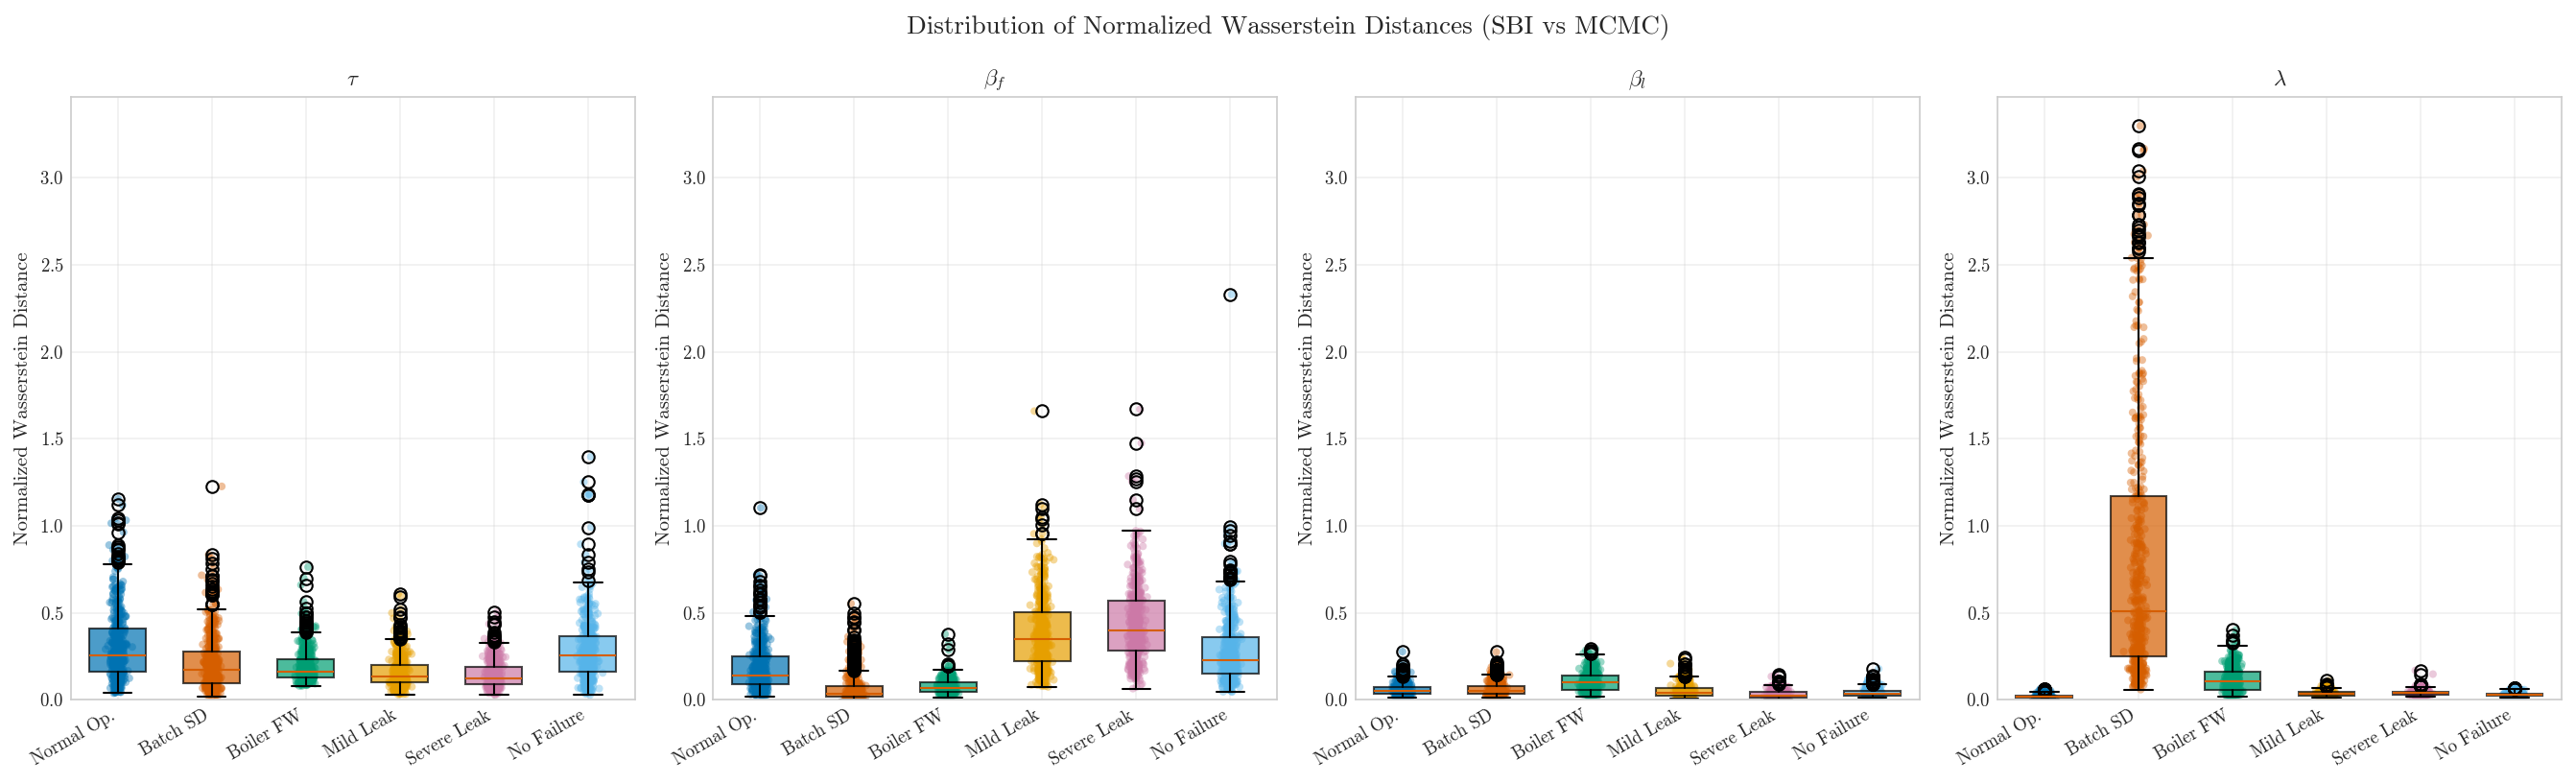

In [7]:
fig, axes = plt.subplots(1, len(PARAMS), figsize=(4.5 * len(PARAMS), 5.5))
if len(PARAMS) == 1:
    axes = [axes]

# Normalize Wasserstein by true parameter
normalized_data_by_param = []
global_max = 0.0
for param_key, _ in PARAMS:
    param_data = []
    for s in ACTIVE_SCENARIOS:
        true_val = SCENARIO_CONFIGS[s][param_key]
        scale = max(abs(true_val), 1e-12)
        vals = [m[f"wasserstein_{param_key}"] / scale for m in all_metrics[s]]
        param_data.append(vals)
        if len(vals) > 0:
            global_max = max(global_max, np.max(vals))
    normalized_data_by_param.append(param_data)

for k, (param_key, param_label) in enumerate(PARAMS):
    ax = axes[k]
    data = normalized_data_by_param[k]

    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ACTIVE_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for j, d in enumerate(data):
        x = np.random.normal(j + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=15, color=ACTIVE_COLORS[j], edgecolor='none')

    ax.set_xticklabels(ACTIVE_LABELS, rotation=30, ha='right')
    ax.set_ylabel('Normalized Wasserstein Distance')
    ax.set_title(param_label)
    ax.grid(True, alpha=0.3)

    ax.set_ylim(0, 1.05 * max(global_max, 1e-12))

fig.suptitle('Distribution of Normalized Wasserstein Distances (SBI vs MCMC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, figures_dir / "wasserstein_distributions")
plt.show()

### Posterior Medians (Paper Fig. 2)

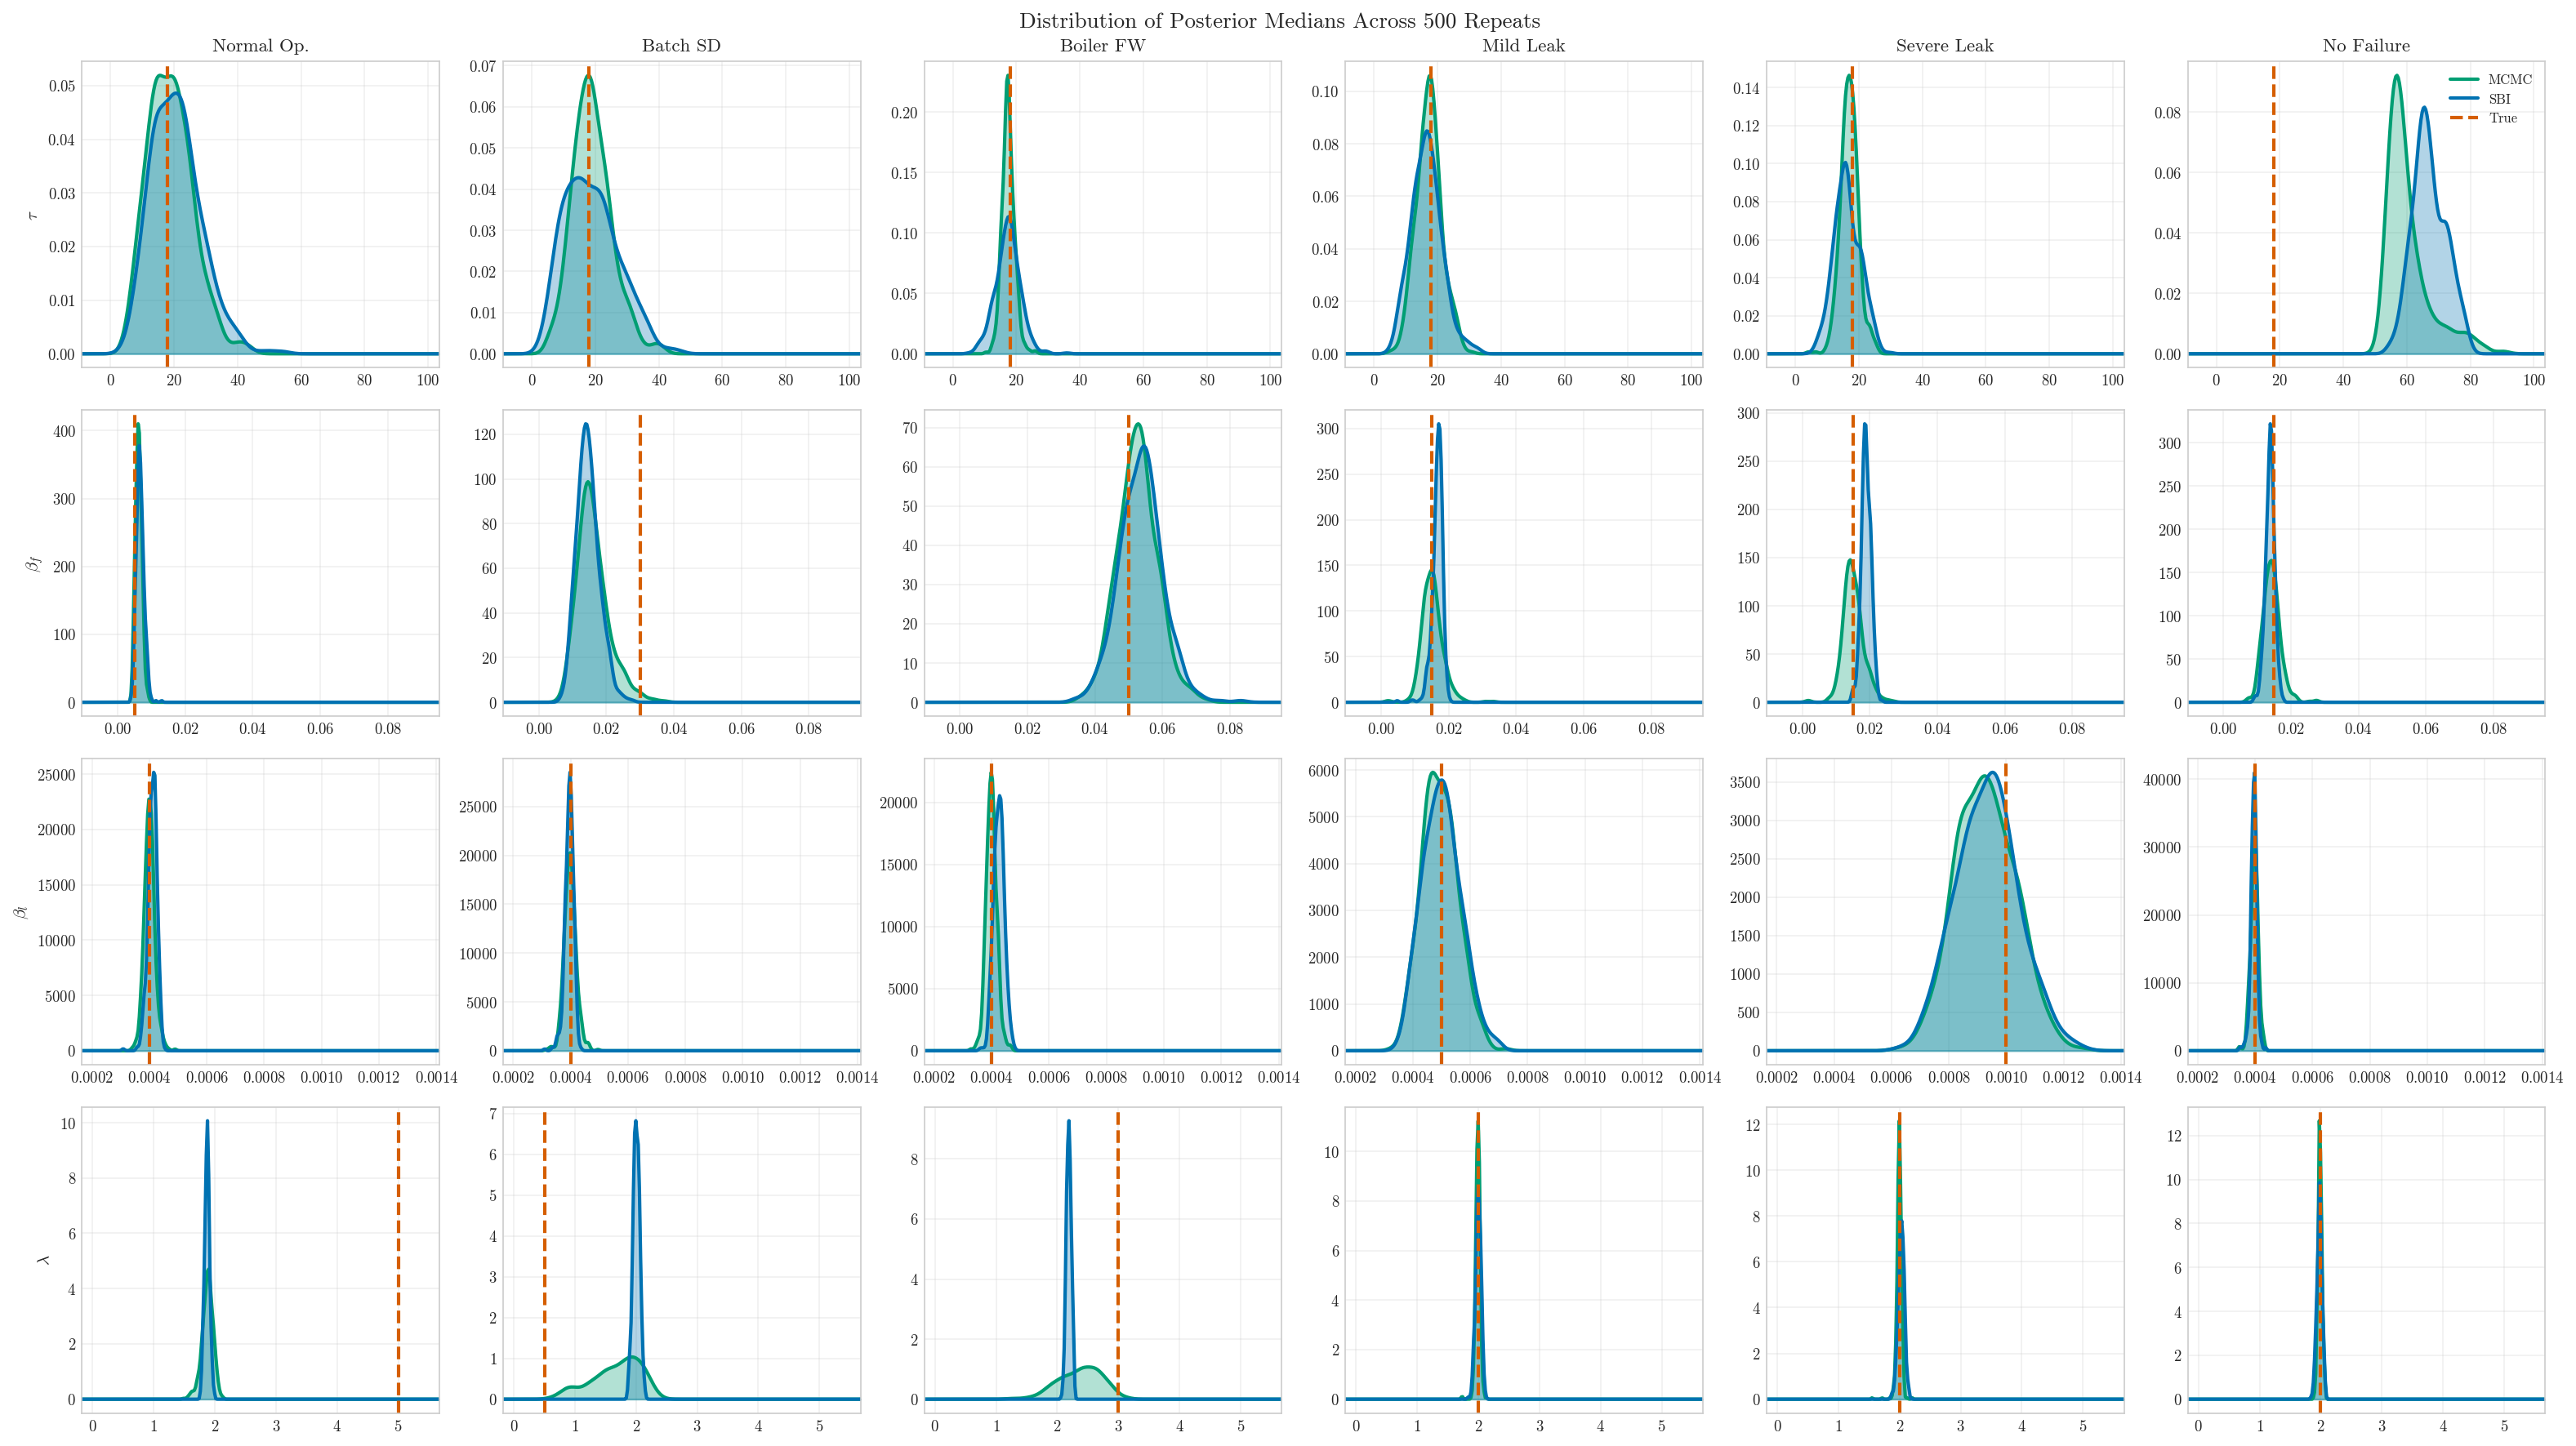

In [8]:
fig, axes = plt.subplots(len(PARAMS), len(ACTIVE_SCENARIOS),
                          figsize=(3.5 * len(ACTIVE_SCENARIOS), 3 * len(PARAMS)))
if len(ACTIVE_SCENARIOS) == 1:
    axes = axes.reshape(-1, 1)

for row, (param_key, param_label) in enumerate(PARAMS):
    true_val = None


    row_mcmc = []
    row_sbi = []
    row_true = []
    for scenario_name in ACTIVE_SCENARIOS:
        row_mcmc.extend([m[f"mcmc_{param_key}_median"] for m in all_metrics[scenario_name]])
        row_sbi.extend([m[f"sbi_{param_key}_median"] for m in all_metrics[scenario_name]])
        row_true.append(SCENARIO_CONFIGS[scenario_name][param_key])

    x_all_row = np.concatenate([np.asarray(row_mcmc), np.asarray(row_sbi), np.asarray(row_true)])
    x_min, x_max = x_all_row.min(), x_all_row.max()

    if param_key == "lambda_rate":
        x_max = max(x_max, 5.0)

    pad = 0.15 * (x_max - x_min + 1e-12)
    x_left, x_right = x_min - pad, x_max + pad
    x_plot = np.linspace(x_left, x_right, 300)

    for col, scenario_name in enumerate(ACTIVE_SCENARIOS):
        ax = axes[row, col]
        config = SCENARIO_CONFIGS[scenario_name]
        true_val = config[param_key]

        mcmc_medians = [m[f"mcmc_{param_key}_median"] for m in all_metrics[scenario_name]]
        sbi_medians = [m[f"sbi_{param_key}_median"] for m in all_metrics[scenario_name]]

        try:
            kde_mcmc = gaussian_kde(mcmc_medians)
            kde_sbi = gaussian_kde(sbi_medians)
            ax.plot(x_plot, kde_mcmc(x_plot), color=MCMC_COLOR, lw=2, label='MCMC')
            ax.fill_between(x_plot, kde_mcmc(x_plot), alpha=0.3, color=MCMC_COLOR)
            ax.plot(x_plot, kde_sbi(x_plot), color=SBI_COLOR, lw=2, label='SBI')
            ax.fill_between(x_plot, kde_sbi(x_plot), alpha=0.3, color=SBI_COLOR)
        except Exception:
            ax.hist(mcmc_medians, bins=30, alpha=0.5, color=MCMC_COLOR, density=True, label='MCMC')
            ax.hist(sbi_medians, bins=30, alpha=0.5, color=SBI_COLOR, density=True, label='SBI')

        ax.set_xlim(x_left, x_right)
        ax.axvline(true_val, color=TRUE_COLOR, ls='--', lw=2, label='True')
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(ACTIVE_LABELS[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(param_label)
        if row == 0 and col == len(ACTIVE_SCENARIOS) - 1:
            ax.legend(fontsize=8)

fig.suptitle('Distribution of Posterior Medians Across 500 Repeats',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, figures_dir / "posterior_medians_distributions")
plt.show()

### CRPS Distributions (Paper Fig. 5 upper)

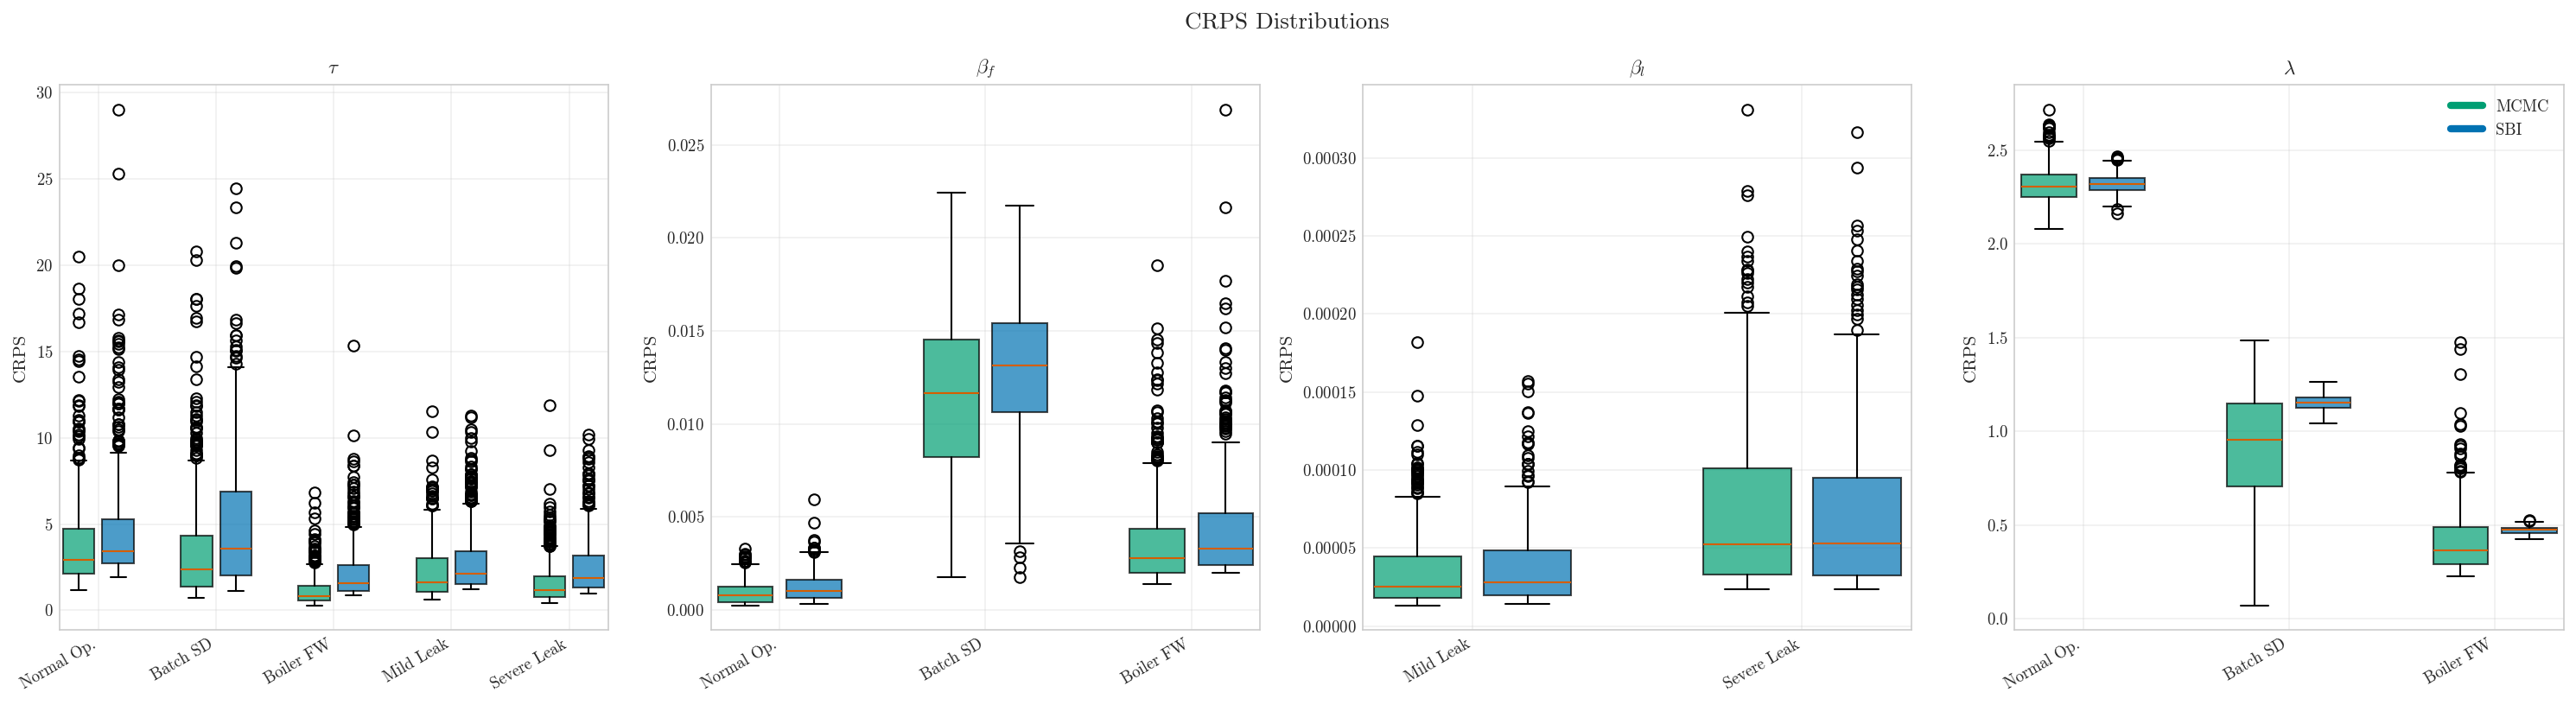

In [9]:
FOULING_NAMES = {'scenario_1_normal_operation', 'scenario_2_batch_shutdown', 'scenario_3_boiler_feedwater'}
LEAKAGE_NAMES = {'scenario_4_mild_tube_leak', 'scenario_5_severe_tube_leak'}

PARAM_RELEVANT = {
    "tau":         FOULING_NAMES | LEAKAGE_NAMES,
    "beta_f":      FOULING_NAMES,
    "beta_l":      LEAKAGE_NAMES,
    "lambda_rate": FOULING_NAMES,
}

cov_scenarios = [(s, l, c) for s, l, c in zip(ACTIVE_SCENARIOS, ACTIVE_LABELS, ACTIVE_COLORS)
                 if 'no_failure' not in s]

fig, axes = plt.subplots(1, len(PARAMS), figsize=(5 * len(PARAMS), 5.5))
if len(PARAMS) == 1:
    axes = [axes]

for k, (param_key, param_label) in enumerate(PARAMS):
    ax = axes[k]
    relevant = PARAM_RELEVANT.get(param_key, set())
    relevant_scenarios = [(s, l, c) for s, l, c in cov_scenarios if s in relevant]
    
    for j, (scenario_name, label, color) in enumerate(relevant_scenarios):
        mcmc_crps = [m[f"mcmc_{param_key}_crps"] for m in all_metrics[scenario_name]]
        sbi_crps = [m[f"sbi_{param_key}_crps"] for m in all_metrics[scenario_name]]
        
        pos_mcmc = j * 3
        pos_sbi = j * 3 + 1
        
        bp_m = ax.boxplot([mcmc_crps], positions=[pos_mcmc], widths=0.8, patch_artist=True)
        bp_s = ax.boxplot([sbi_crps], positions=[pos_sbi], widths=0.8, patch_artist=True)
        bp_m['boxes'][0].set_facecolor(MCMC_COLOR)
        bp_m['boxes'][0].set_alpha(0.7)
        bp_s['boxes'][0].set_facecolor(SBI_COLOR)
        bp_s['boxes'][0].set_alpha(0.7)
    
    positions = [j * 3 + 0.5 for j in range(len(relevant_scenarios))]
    ax.set_xticks(positions)
    ax.set_xticklabels([l for _, l, _ in relevant_scenarios], rotation=30, ha='right')
    ax.set_ylabel('CRPS')
    ax.set_title(param_label)
    ax.grid(True, alpha=0.3)

legend_elements = [
    Line2D([0], [0], color=MCMC_COLOR, lw=4, label='MCMC'),
    Line2D([0], [0], color=SBI_COLOR, lw=4, label='SBI'),
]
axes[-1].legend(handles=legend_elements, loc='upper right')

fig.suptitle('CRPS Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, figures_dir / "crps_distributions")
plt.show()


### Coverage Calibration (Paper Fig. 5 lower)

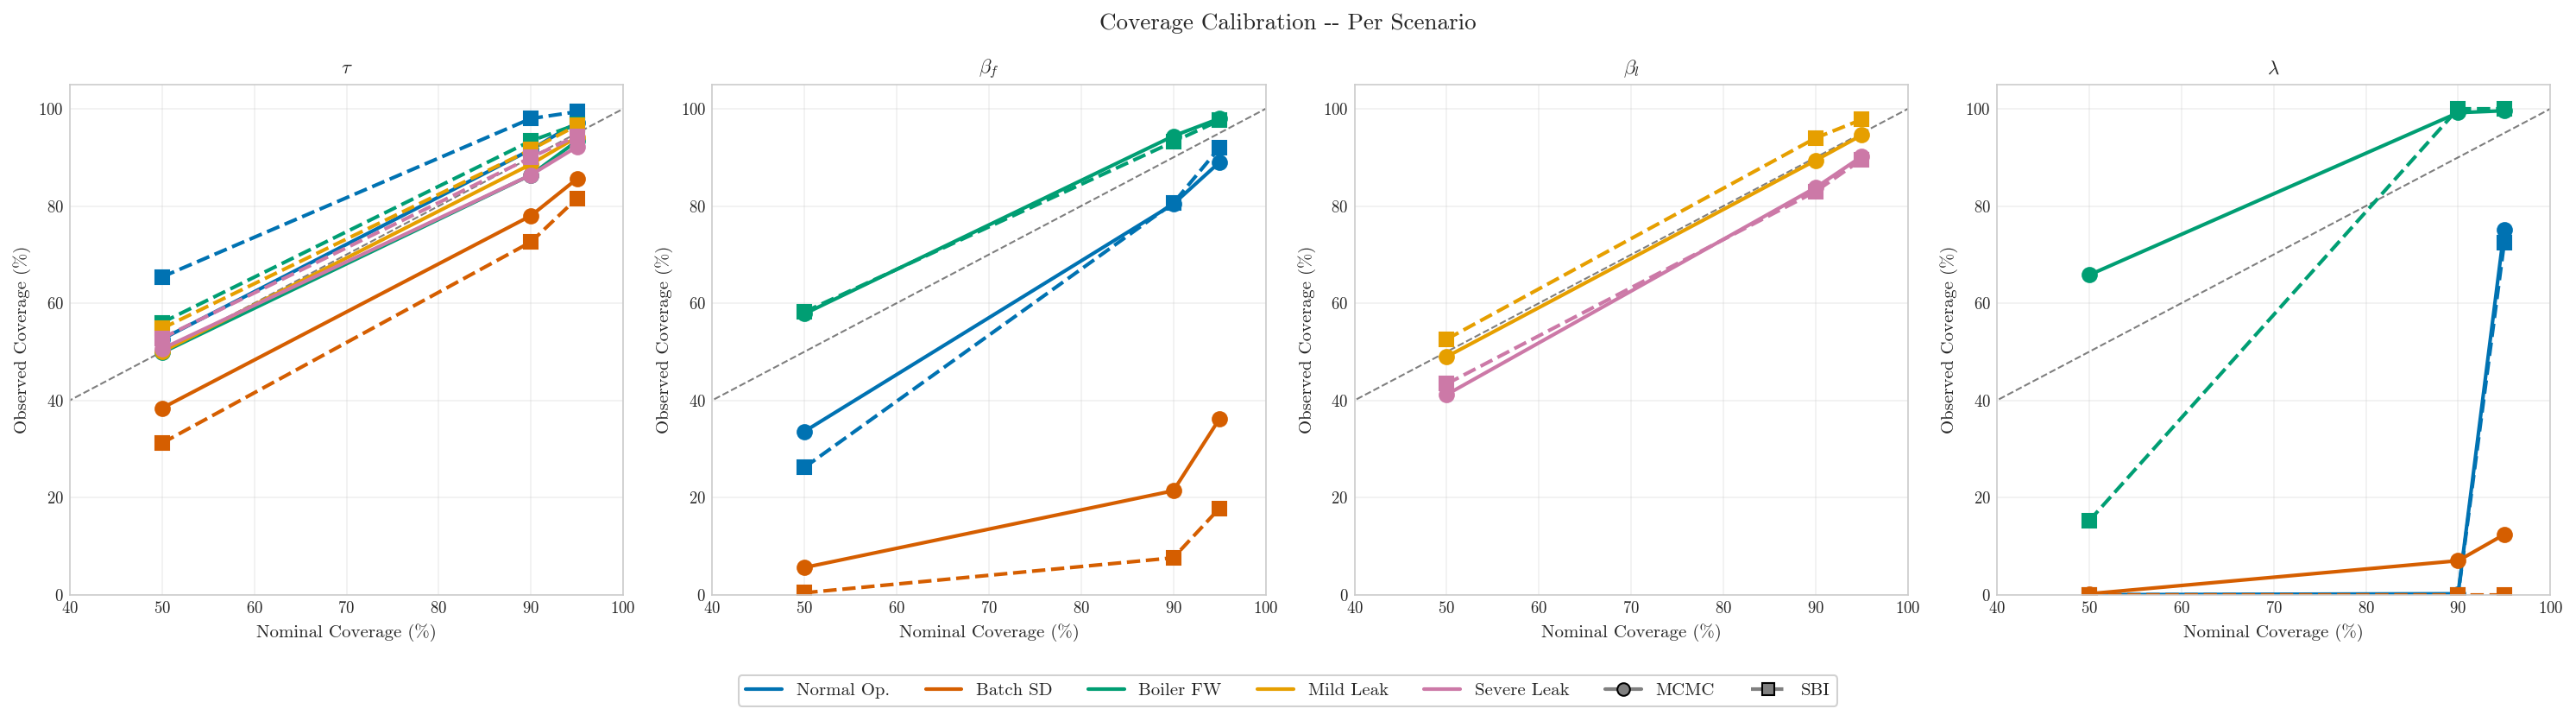

In [10]:
coverage_levels = [50, 90, 95]

cov_scenarios = [(s, l, c) for s, l, c in zip(ACTIVE_SCENARIOS, ACTIVE_LABELS, ACTIVE_COLORS)
                 if 'no_failure' not in s]

FOULING_NAMES = {'scenario_1_normal_operation', 'scenario_2_batch_shutdown', 'scenario_3_boiler_feedwater'}
LEAKAGE_NAMES = {'scenario_4_mild_tube_leak', 'scenario_5_severe_tube_leak'}

PARAM_RELEVANT = {
    "tau":         FOULING_NAMES | LEAKAGE_NAMES,
    "beta_f":      FOULING_NAMES,
    "beta_l":      LEAKAGE_NAMES,
    "lambda_rate": FOULING_NAMES,
}

fig, axes = plt.subplots(1, len(PARAMS), figsize=(5 * len(PARAMS), 5.5))
if len(PARAMS) == 1:
    axes = [axes]

for k, (param_key, param_label) in enumerate(PARAMS):
    ax = axes[k]
    ax.plot([0, 100], [0, 100], 'k--', lw=1, alpha=0.5)
    relevant = PARAM_RELEVANT.get(param_key, set())
    
    for scenario_name, label, color in cov_scenarios:
        if scenario_name not in relevant:
            continue
        mc_cov = [np.mean([m[f"mcmc_{param_key}_coverage_{l}"] for m in all_metrics[scenario_name]]) * 100
                  for l in coverage_levels]
        sb_cov = [np.mean([m[f"sbi_{param_key}_coverage_{l}"] for m in all_metrics[scenario_name]]) * 100
                  for l in coverage_levels]
        
        ax.plot(coverage_levels, mc_cov, '-o', color=color, linewidth=2, markersize=8)
        ax.plot(coverage_levels, sb_cov, '--s', color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Nominal Coverage (%)')
    ax.set_ylabel('Observed Coverage (%)')
    ax.set_title(param_label)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(40, 100)
    ax.set_ylim(0, 105)

_legend_handles = (
    [Line2D([], [], color=c, linewidth=2, label=l)
     for _, l, c in cov_scenarios]
    + [Line2D([], [], color='gray', linewidth=2, linestyle='-',
              marker='o', markersize=7, markeredgecolor='black', label='MCMC'),
       Line2D([], [], color='gray', linewidth=2, linestyle='--',
              marker='s', markersize=7, markeredgecolor='black', label='SBI')]
)
fig.legend(handles=_legend_handles, loc='lower center',
           ncol=len(cov_scenarios) + 2, fontsize=10, frameon=True,
           framealpha=0.9, edgecolor='#ccc')

fig.suptitle('Coverage Calibration -- Per Scenario', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 1])
save_fig(fig, figures_dir / "coverage_calibration")
plt.show()


### MCMC vs SBI Scatter (Paper Fig. 3)

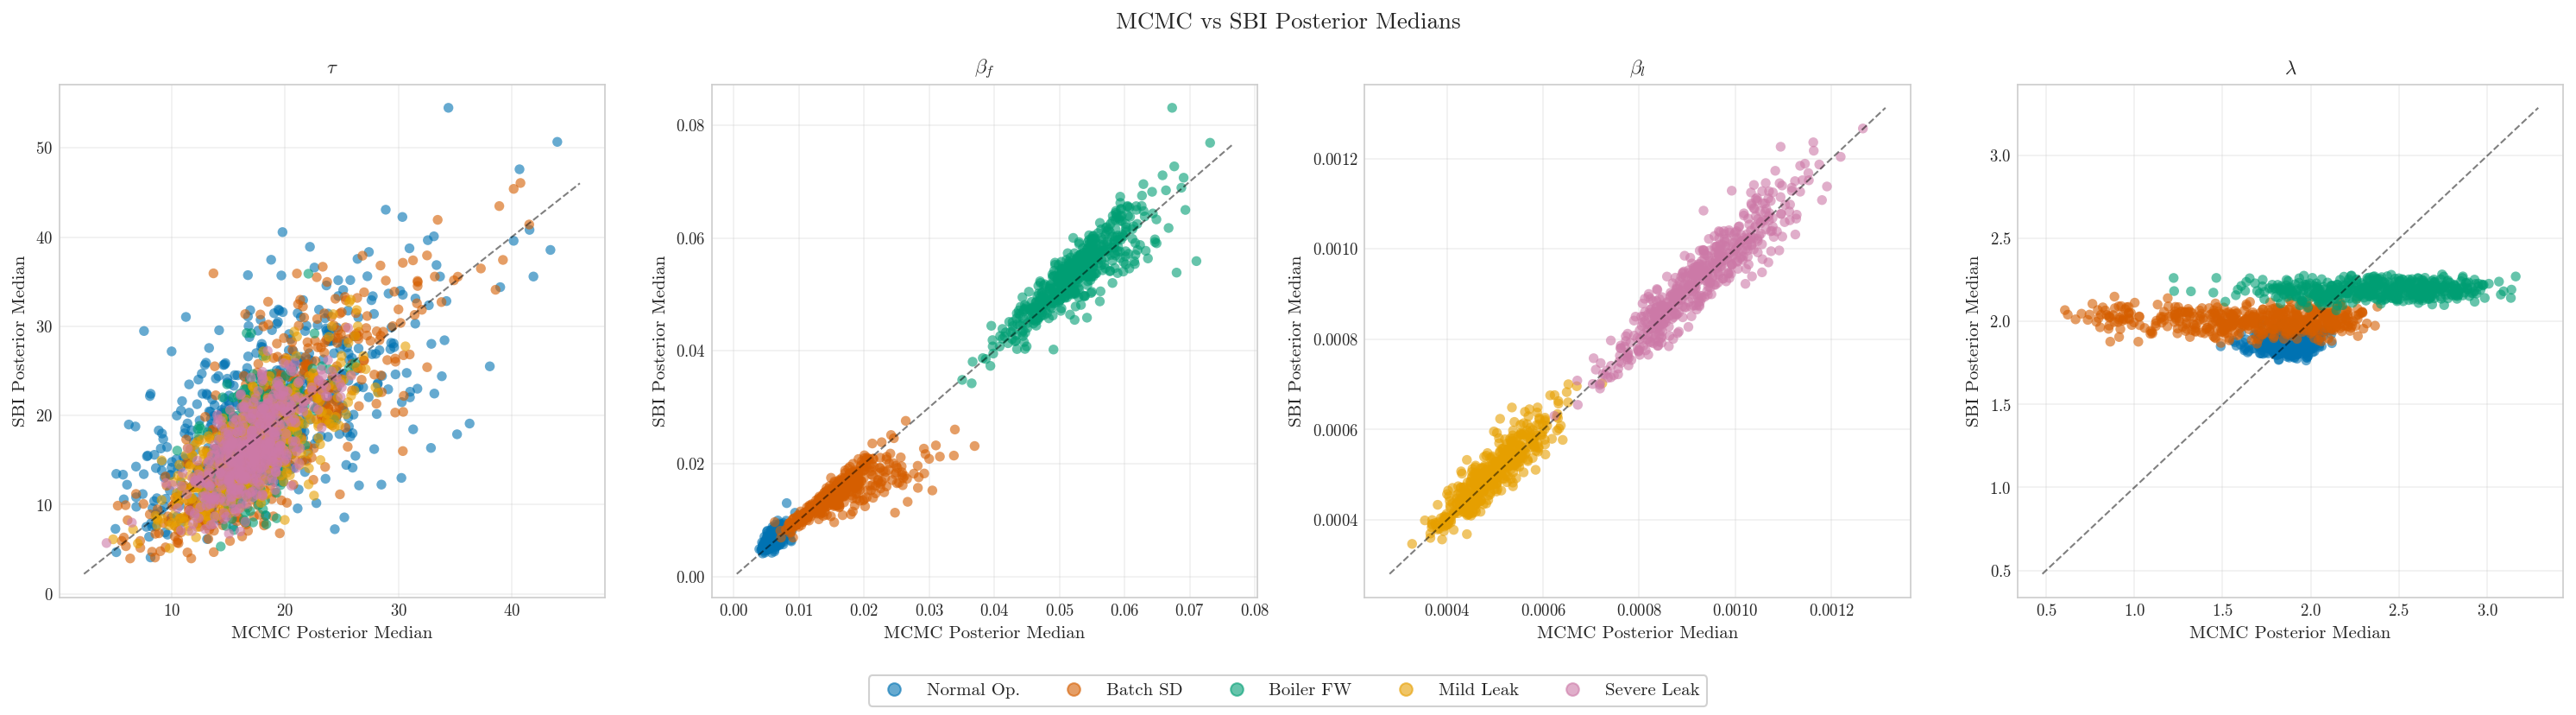

In [11]:
FOULING_NAMES = {'scenario_1_normal_operation', 'scenario_2_batch_shutdown', 'scenario_3_boiler_feedwater'}
LEAKAGE_NAMES = {'scenario_4_mild_tube_leak', 'scenario_5_severe_tube_leak'}

PARAM_RELEVANT = {
    "tau":         FOULING_NAMES | LEAKAGE_NAMES,
    "beta_f":      FOULING_NAMES,
    "beta_l":      LEAKAGE_NAMES,
    "lambda_rate": FOULING_NAMES,
}

scat_scenarios = [(s, l, c) for s, l, c in zip(ACTIVE_SCENARIOS, ACTIVE_LABELS, ACTIVE_COLORS)
                  if 'no_failure' not in s]

fig, axes = plt.subplots(1, len(PARAMS), figsize=(5 * len(PARAMS), 5.5))
if len(PARAMS) == 1:
    axes = [axes]

for k, (param_key, param_label) in enumerate(PARAMS):
    ax = axes[k]
    relevant = PARAM_RELEVANT.get(param_key, set())
    
    for scenario_name, label, color in scat_scenarios:
        if scenario_name not in relevant:
            continue
        mcmc_m = [m[f"mcmc_{param_key}_median"] for m in all_metrics[scenario_name]]
        sbi_m = [m[f"sbi_{param_key}_median"] for m in all_metrics[scenario_name]]
        ax.scatter(mcmc_m, sbi_m, alpha=0.6, s=30, color=color,
                   edgecolor='none')
    
    lims = ax.get_xlim()
    ax.plot(lims, lims, 'k--', alpha=0.5, lw=1)
    ax.set_xlabel('MCMC Posterior Median')
    ax.set_ylabel('SBI Posterior Median')
    ax.set_title(param_label)
    ax.grid(True, alpha=0.3)

_legend_handles = [Line2D([], [], color=c, marker='o', linestyle='', markersize=7,
                          alpha=0.6, label=l) for _, l, c in scat_scenarios]
fig.legend(handles=_legend_handles, loc='lower center',
           ncol=len(scat_scenarios), fontsize=10, frameon=True,
           framealpha=0.9, edgecolor='#ccc')

fig.suptitle('MCMC vs SBI Posterior Medians',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 1])
save_fig(fig, figures_dir / "mcmc_vs_sbi_scatter")
plt.show()

## Posterior Pairplots

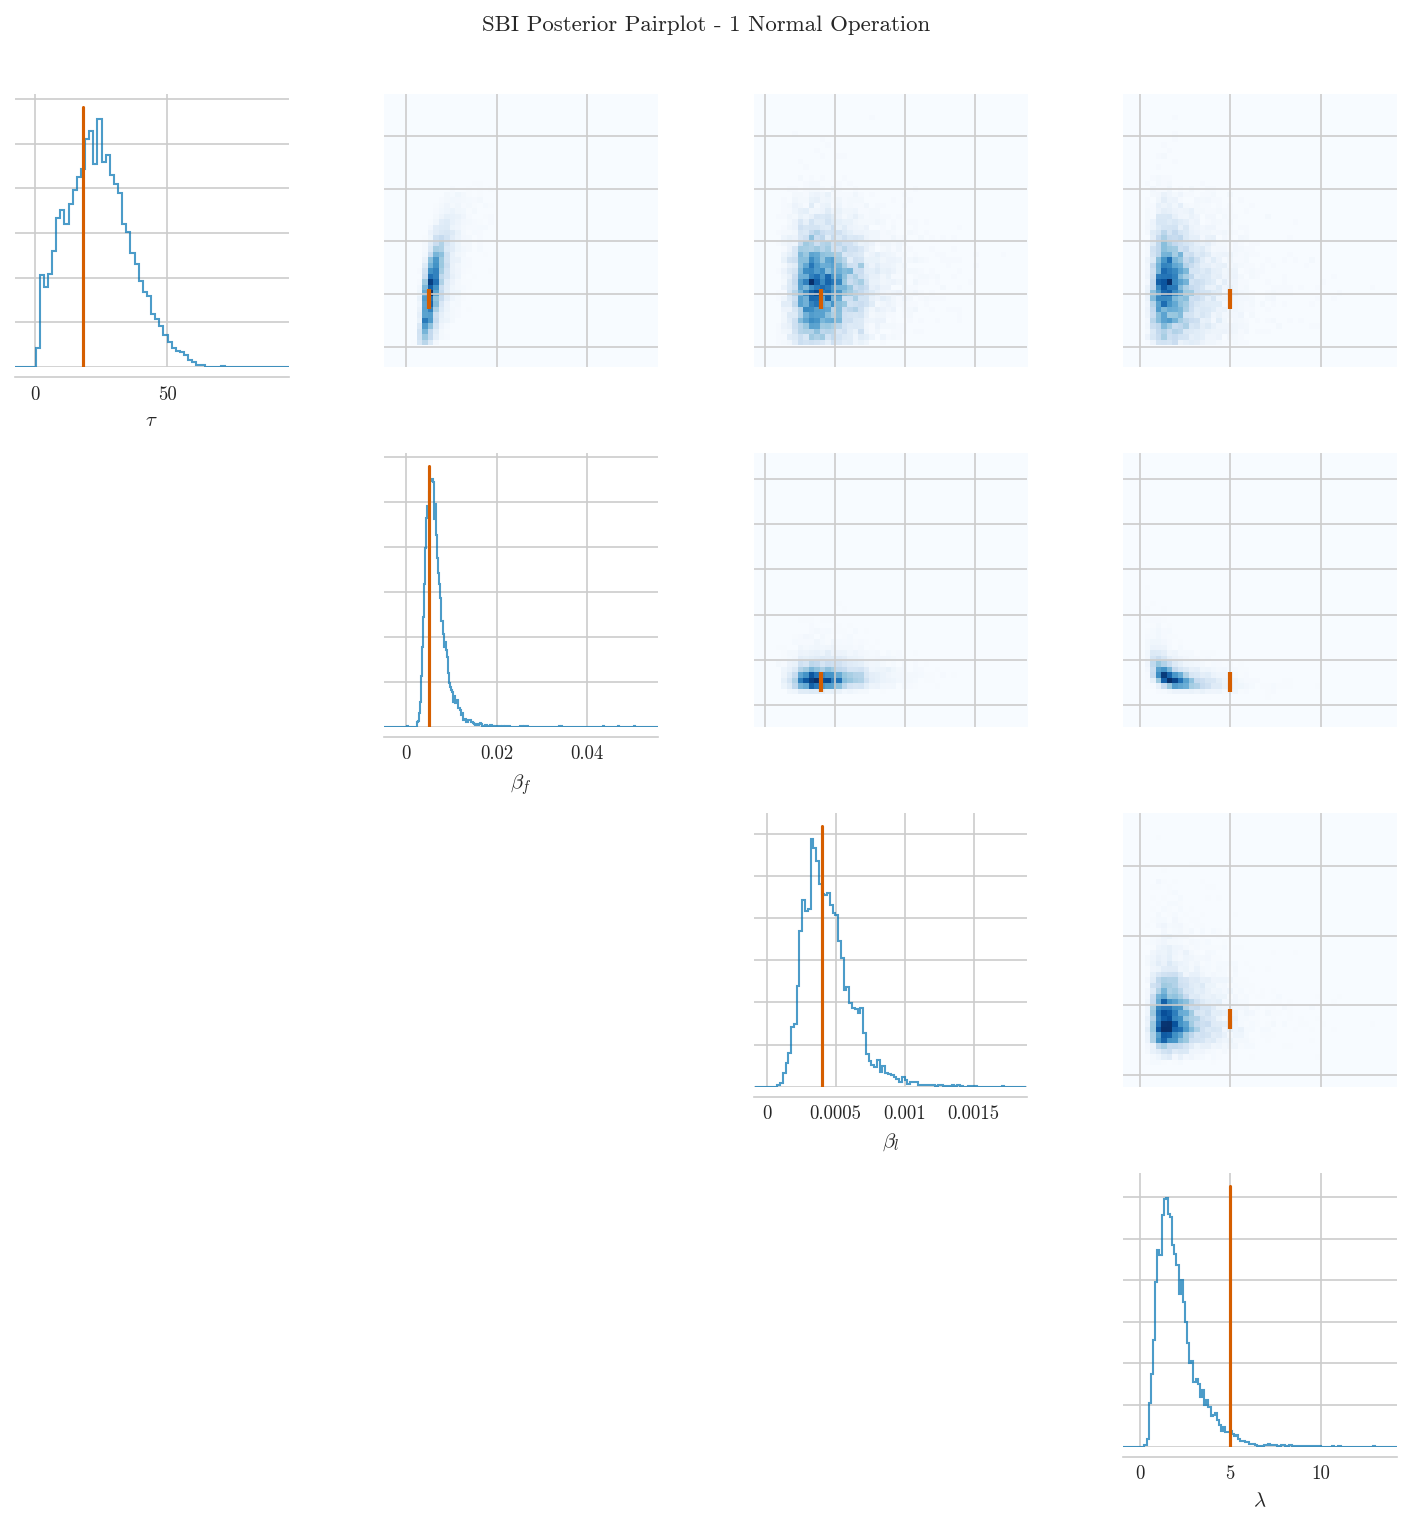

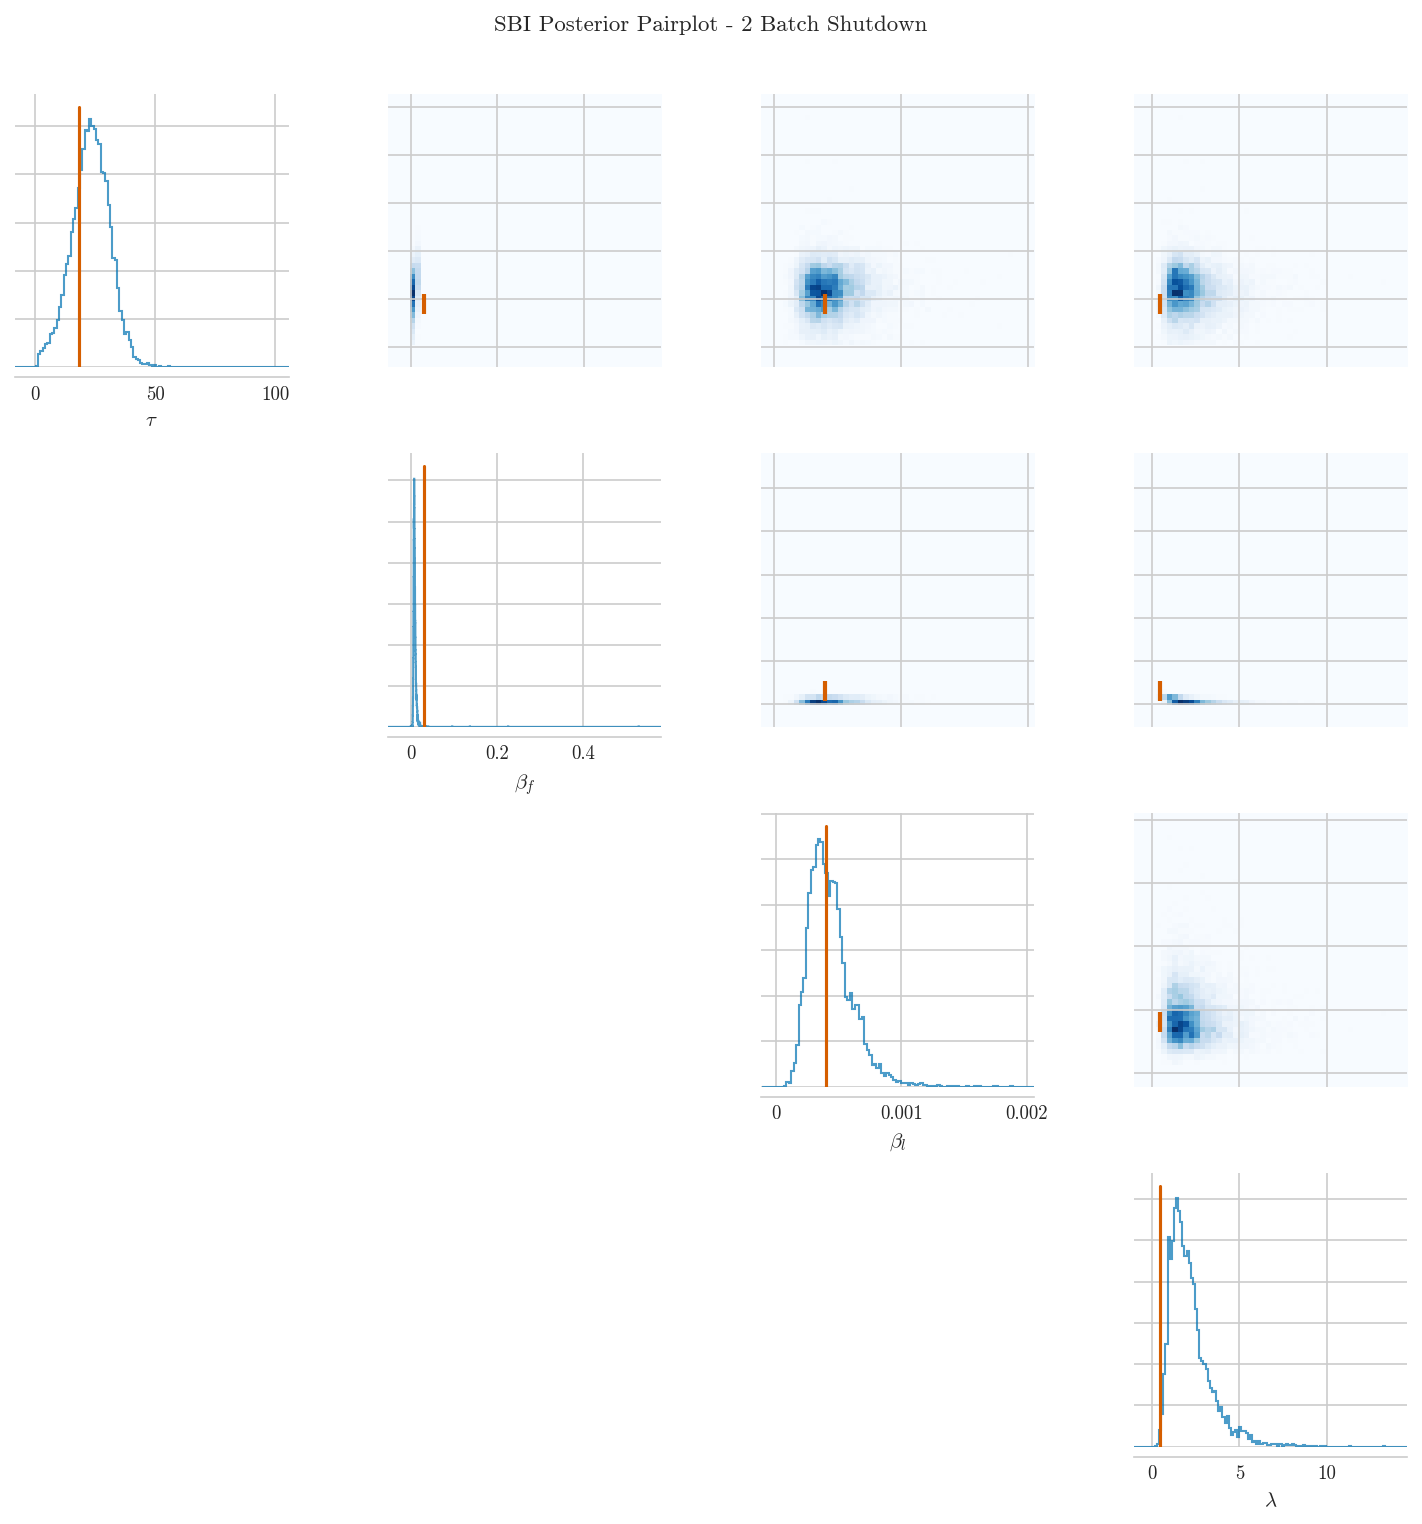

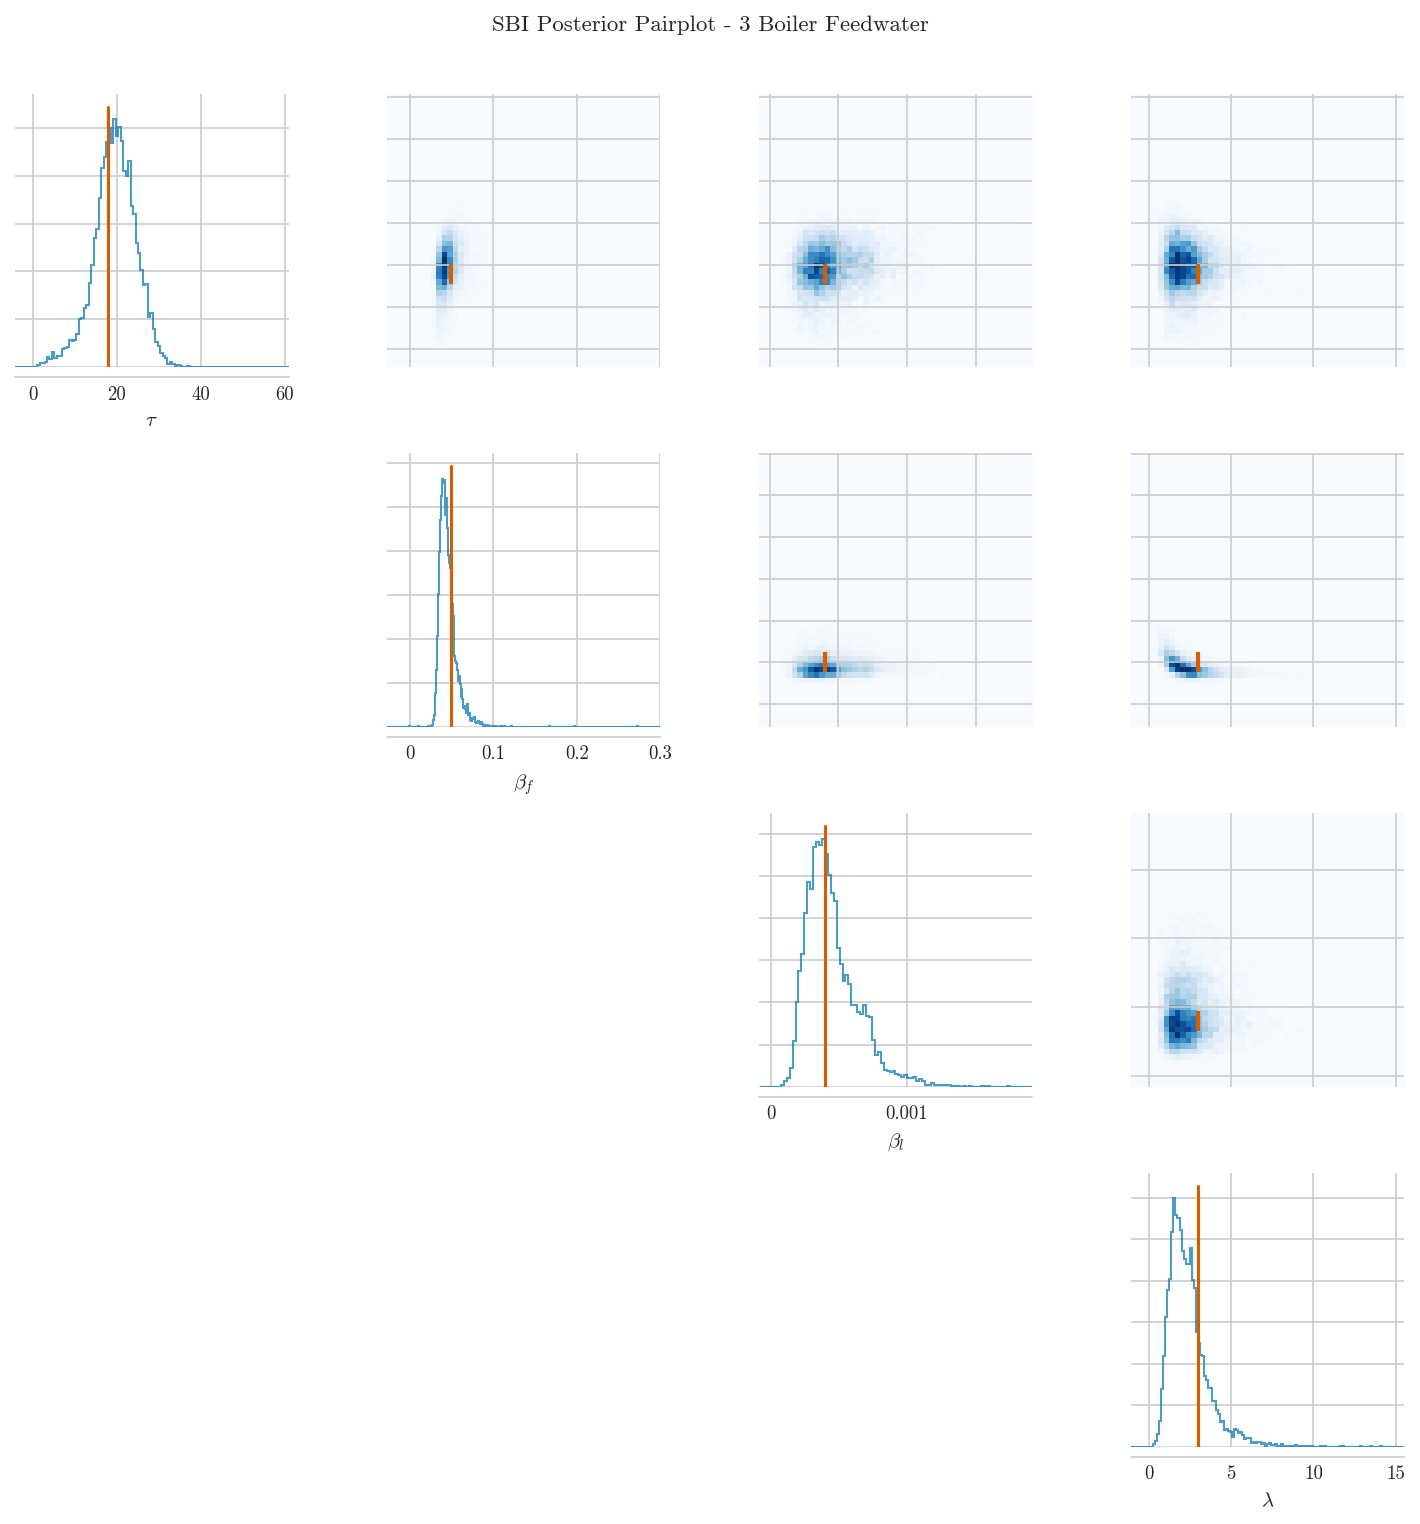

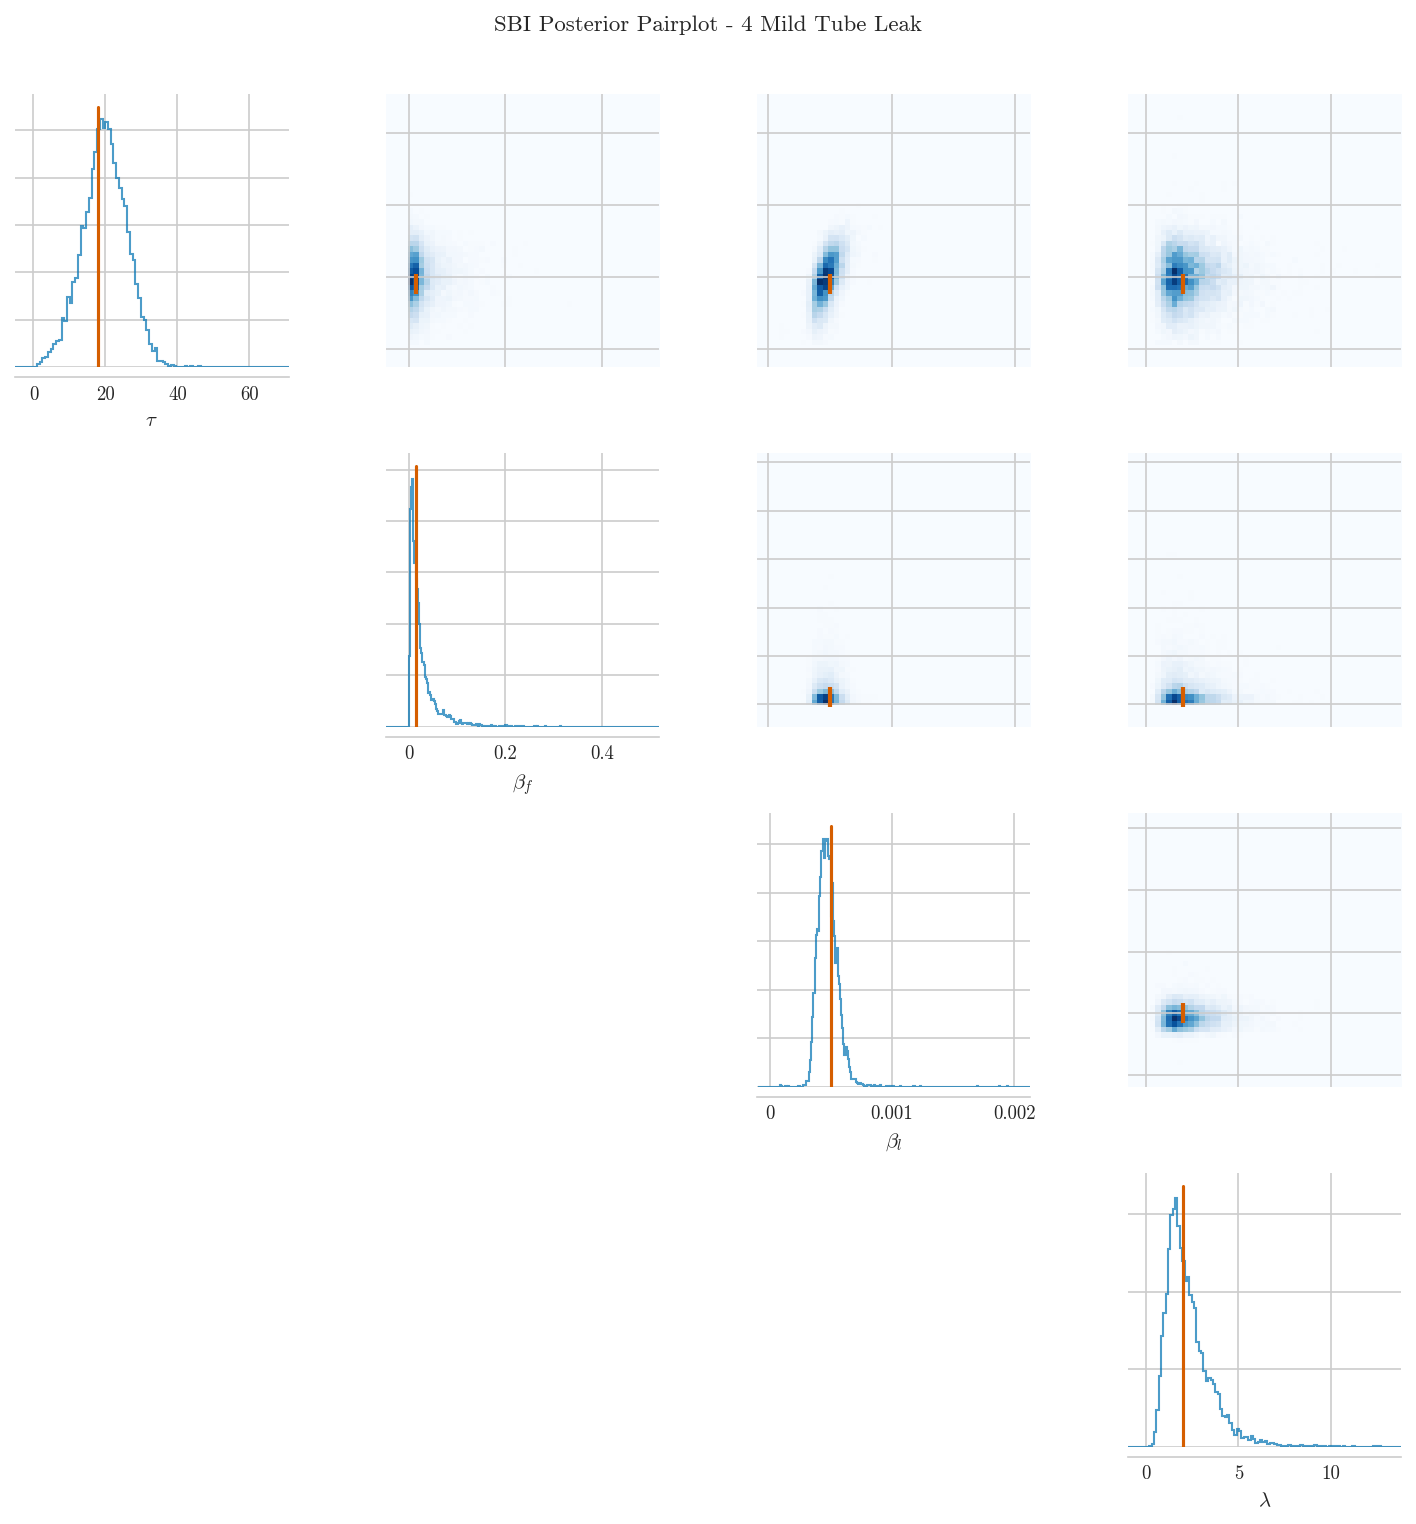

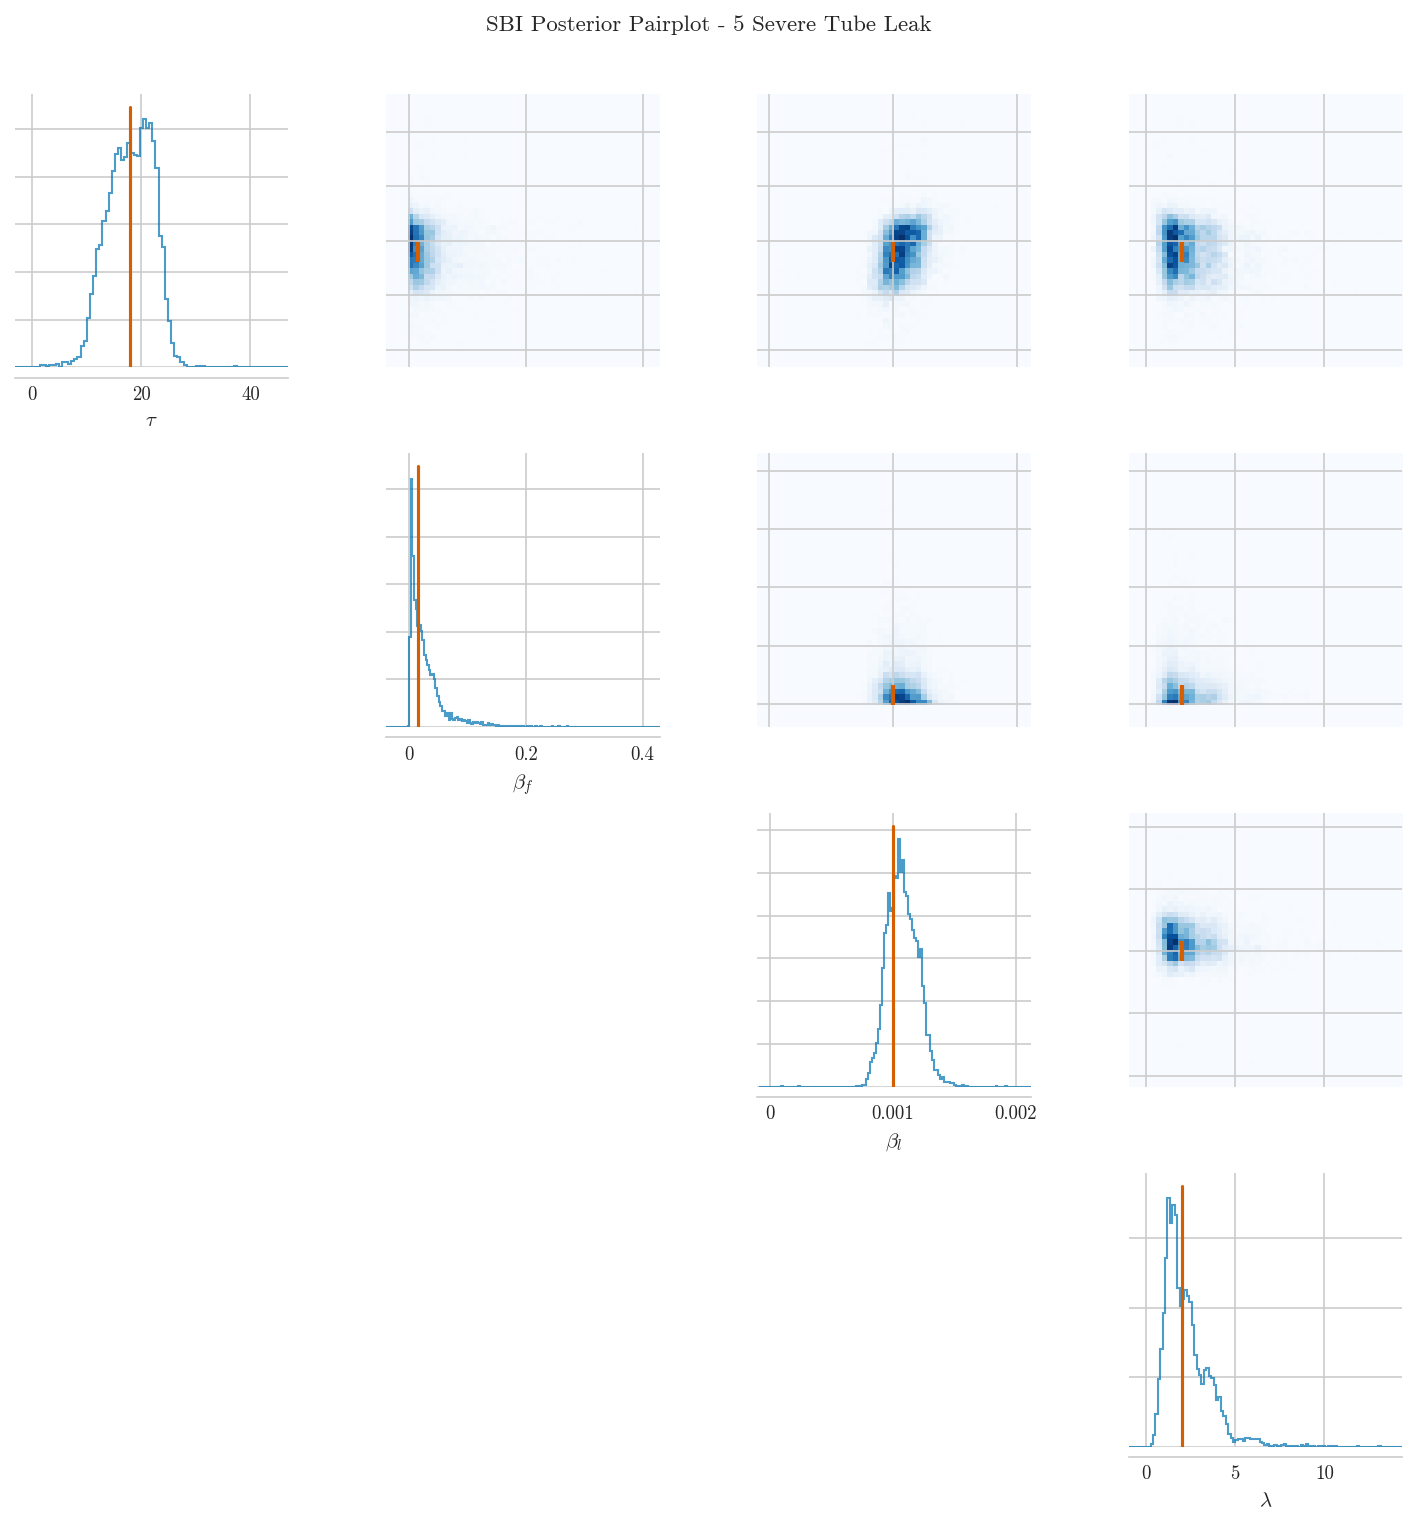

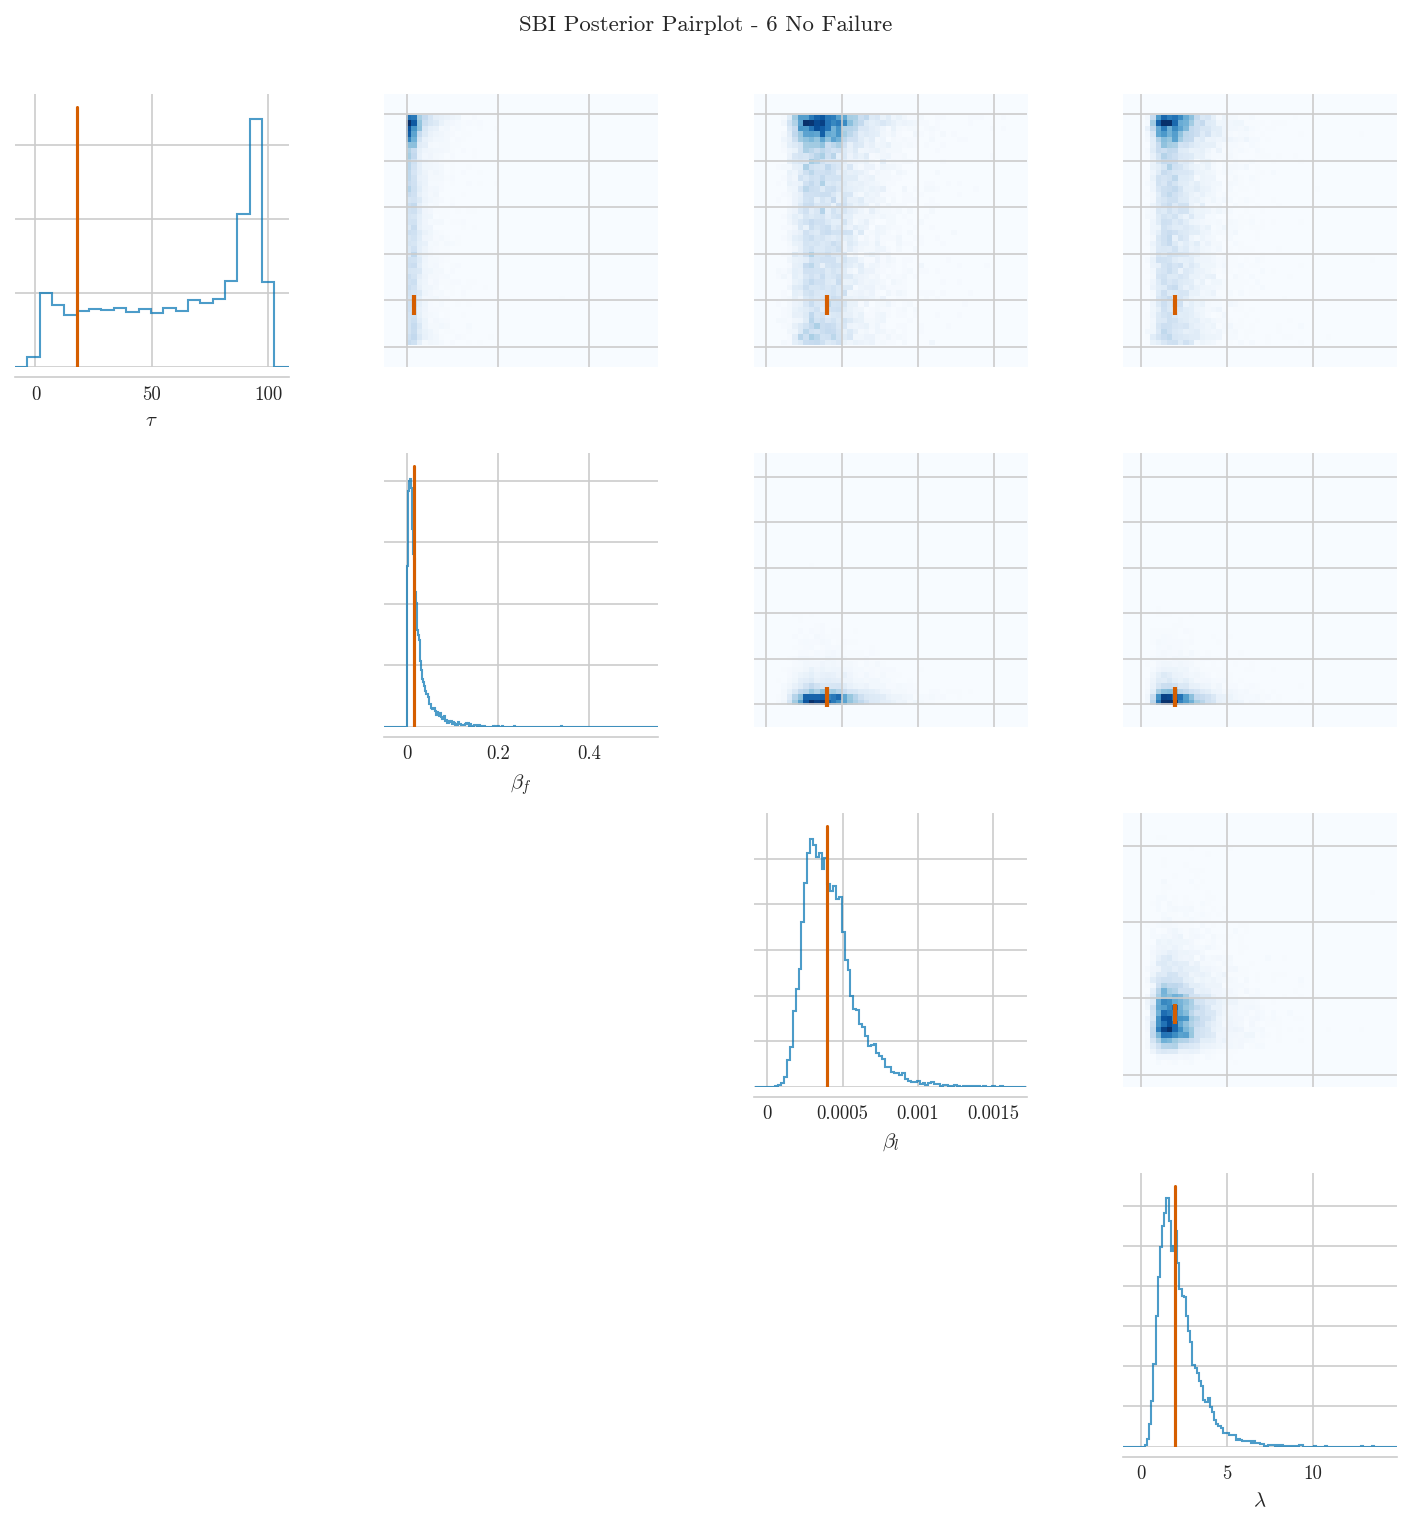

In [32]:
from sbi.analysis import pairplot as sbi_pairplot
from matplotlib.patches import Patch

REPEAT_IDX = 0  # Change to view a different noise realisation (0-499)

for scenario_name in ACTIVE_SCENARIOS:
    config = SCENARIO_CONFIGS[scenario_name]
    sbi = sbi_results[scenario_name]
    label = scenario_name.replace("scenario_", "").replace("_", " ").title()

    sbi_samples = np.column_stack([
        sbi["tau_samples"][REPEAT_IDX],
        sbi["beta_f_samples"][REPEAT_IDX],
        sbi["beta_l_samples"][REPEAT_IDX],
        sbi["lambda_rate_samples"][REPEAT_IDX],
    ])

    true_point = np.array([[
        config["tau"],
        config["beta_f"],
        config["beta_l"],
        config["lambda_rate"],
    ]])
    labels_sbi = [r"$\tau$", r"$\beta_f$", r"$\beta_l$", r"$\lambda$"]

    fig, _ = sbi_pairplot(
        torch.tensor(sbi_samples, dtype=torch.float32),
        points=torch.tensor(true_point, dtype=torch.float32),
        labels=labels_sbi,
        upper="hist",
        diag="hist",
        figsize=(10, 10),
        diag_kwargs={"mpl_kwargs": {"color": SBI_COLOR, "alpha": 0.7}},
        upper_kwargs={"mpl_kwargs": {"cmap": "Blues"}},
        fig_kwargs={
            "points_colors": [TRUE_COLOR],
            "points_offdiag": {"marker": "|", "markersize": 10, "markeredgewidth": 2},
            "legend": False,
        },
    )
    fig.suptitle(f"SBI Posterior Pairplot - {label}", y=1.01, fontsize=11)
    plt.tight_layout()
    save_fig(fig, figures_dir / f"pairplot_sbi_{scenario_name}")
    plt.show()

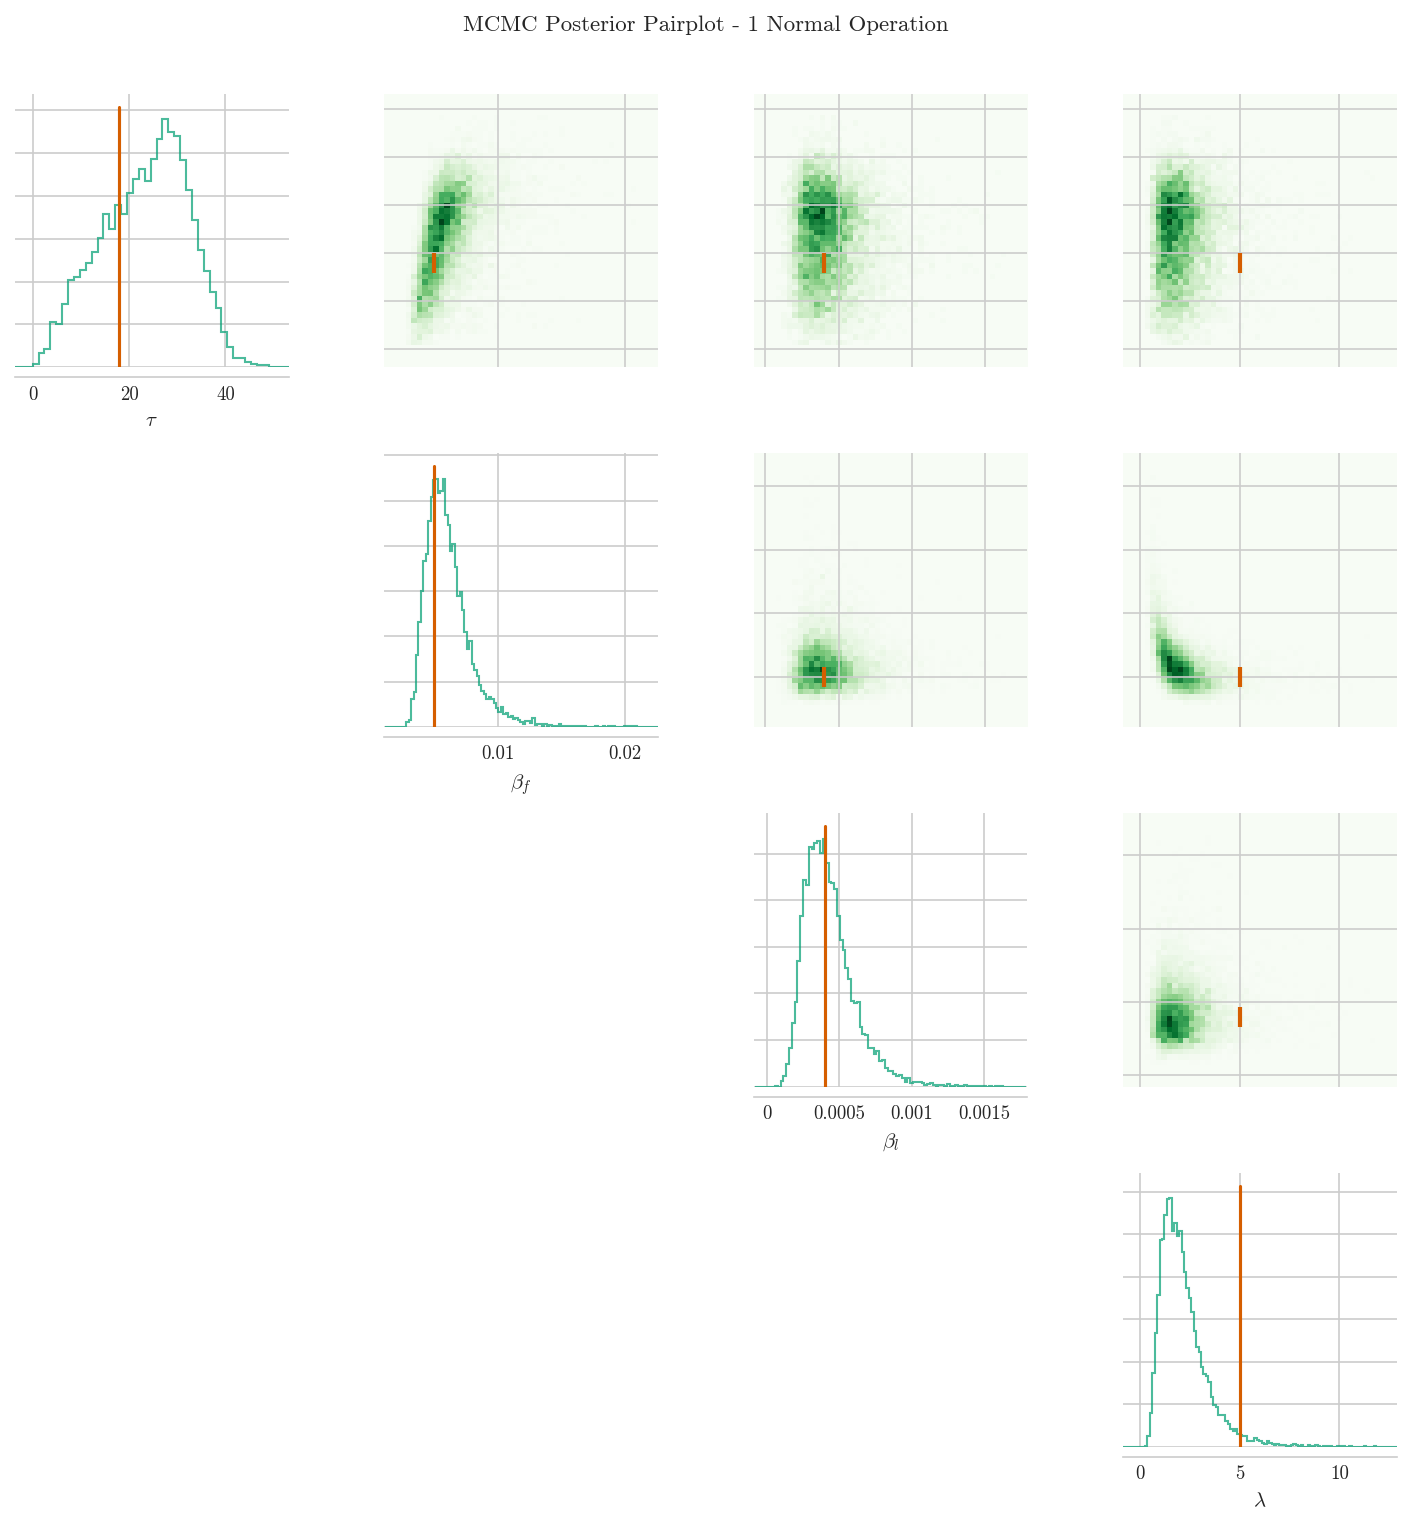

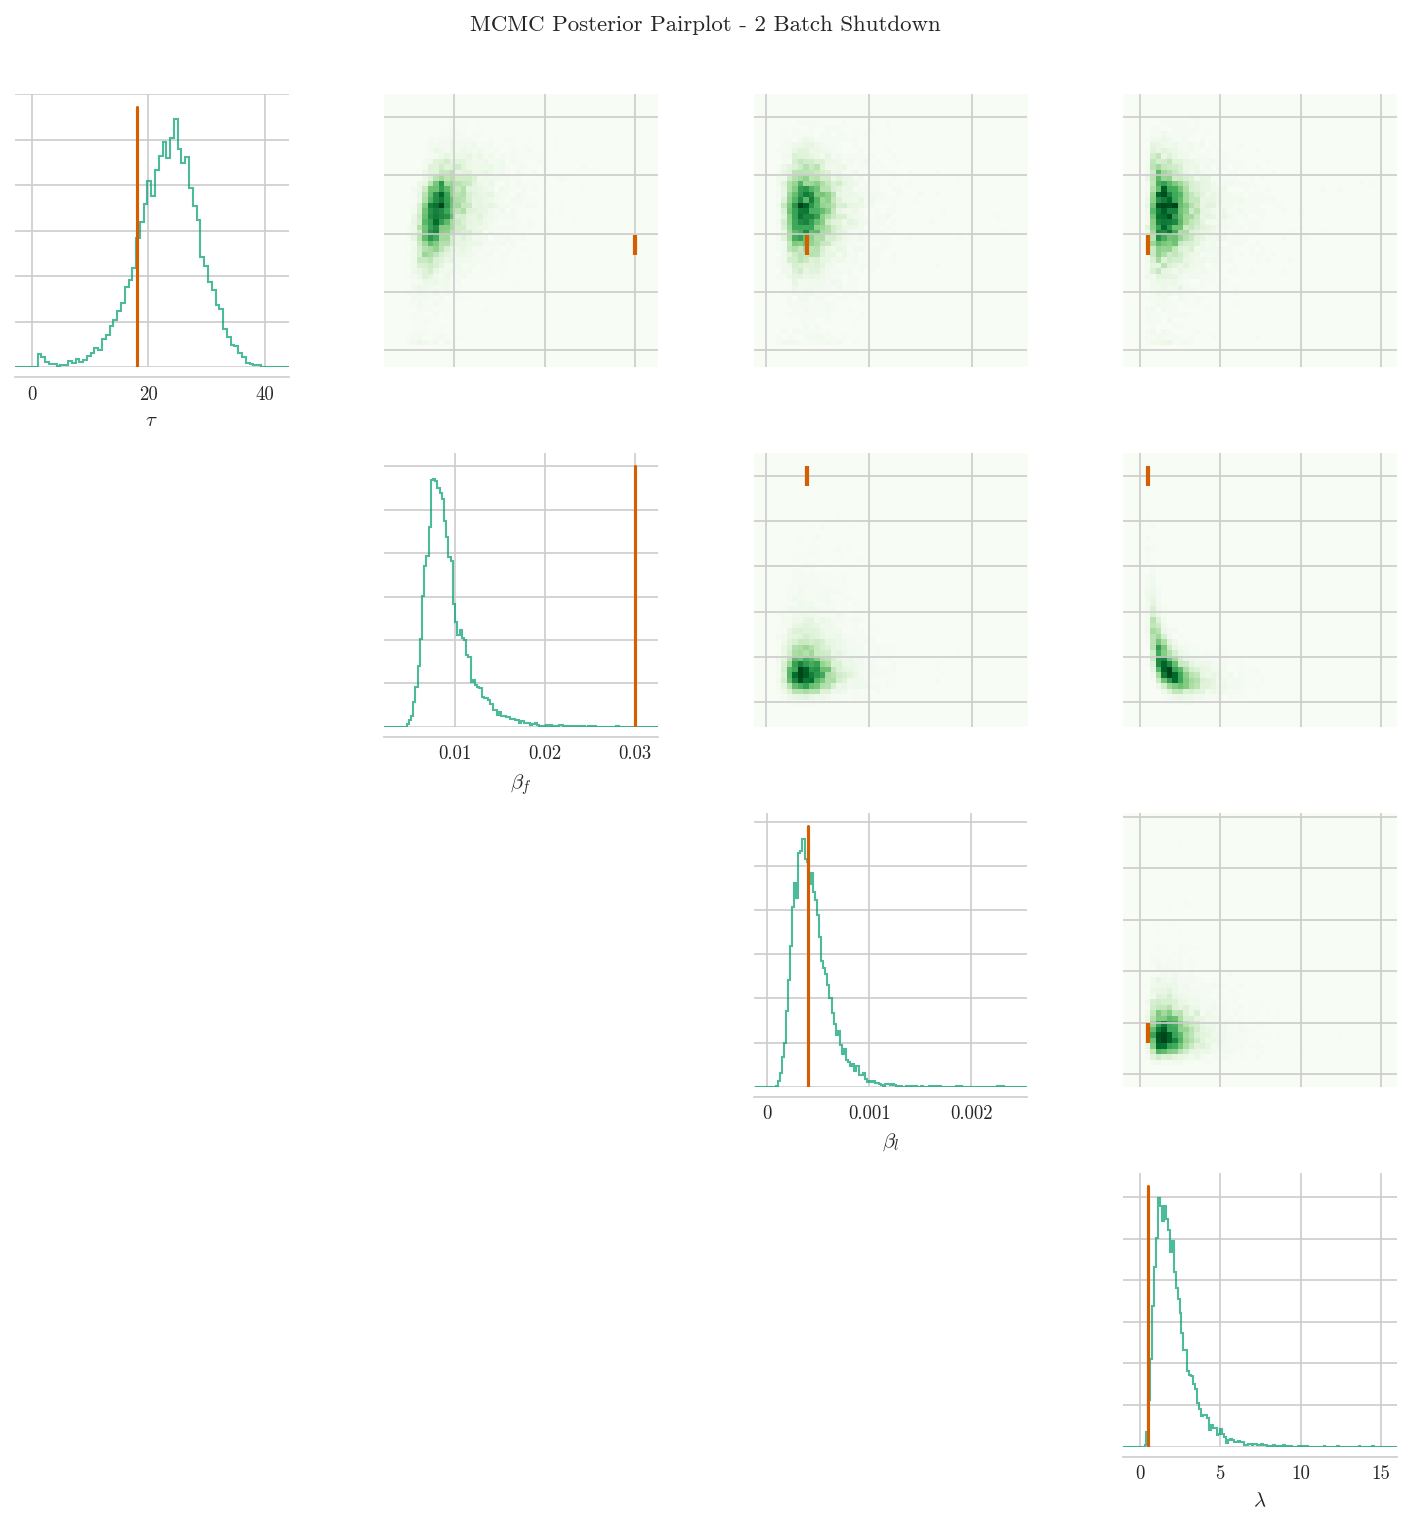

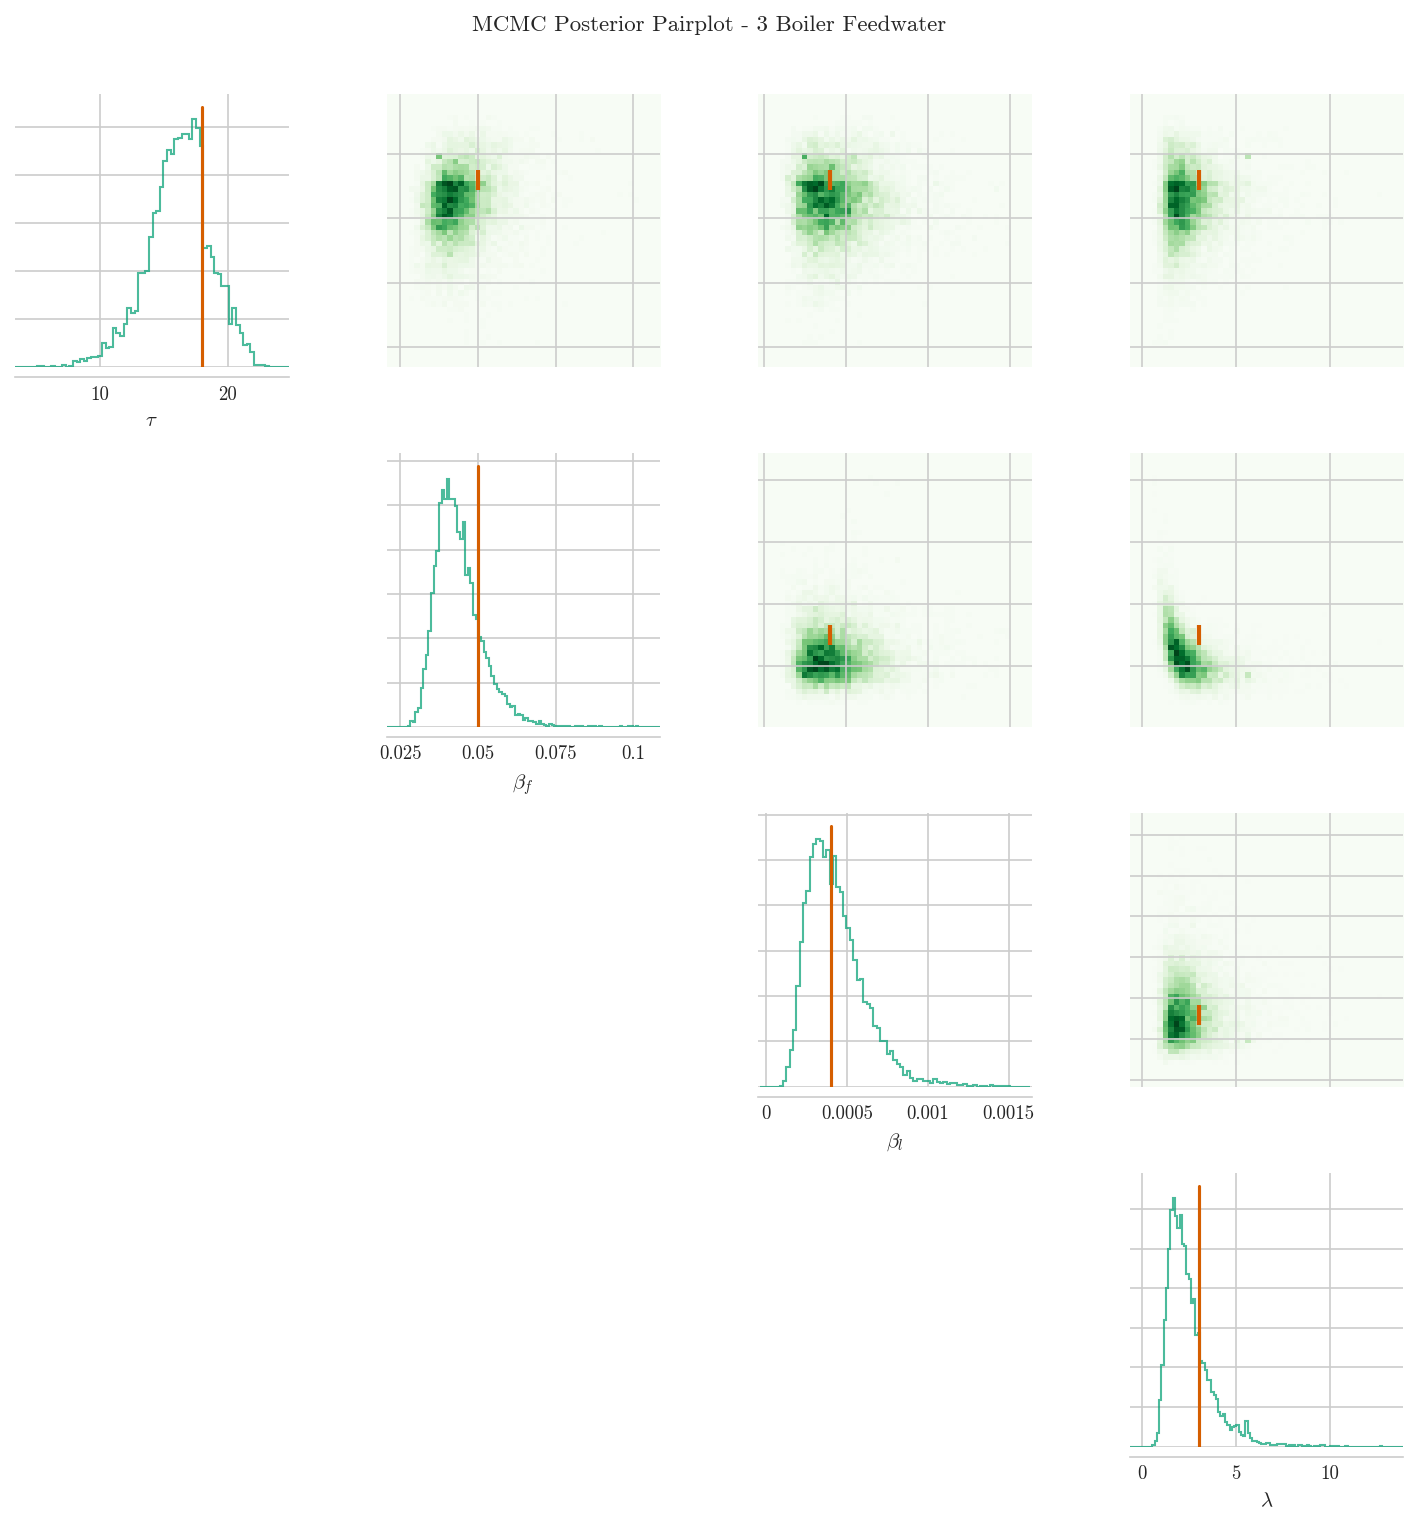

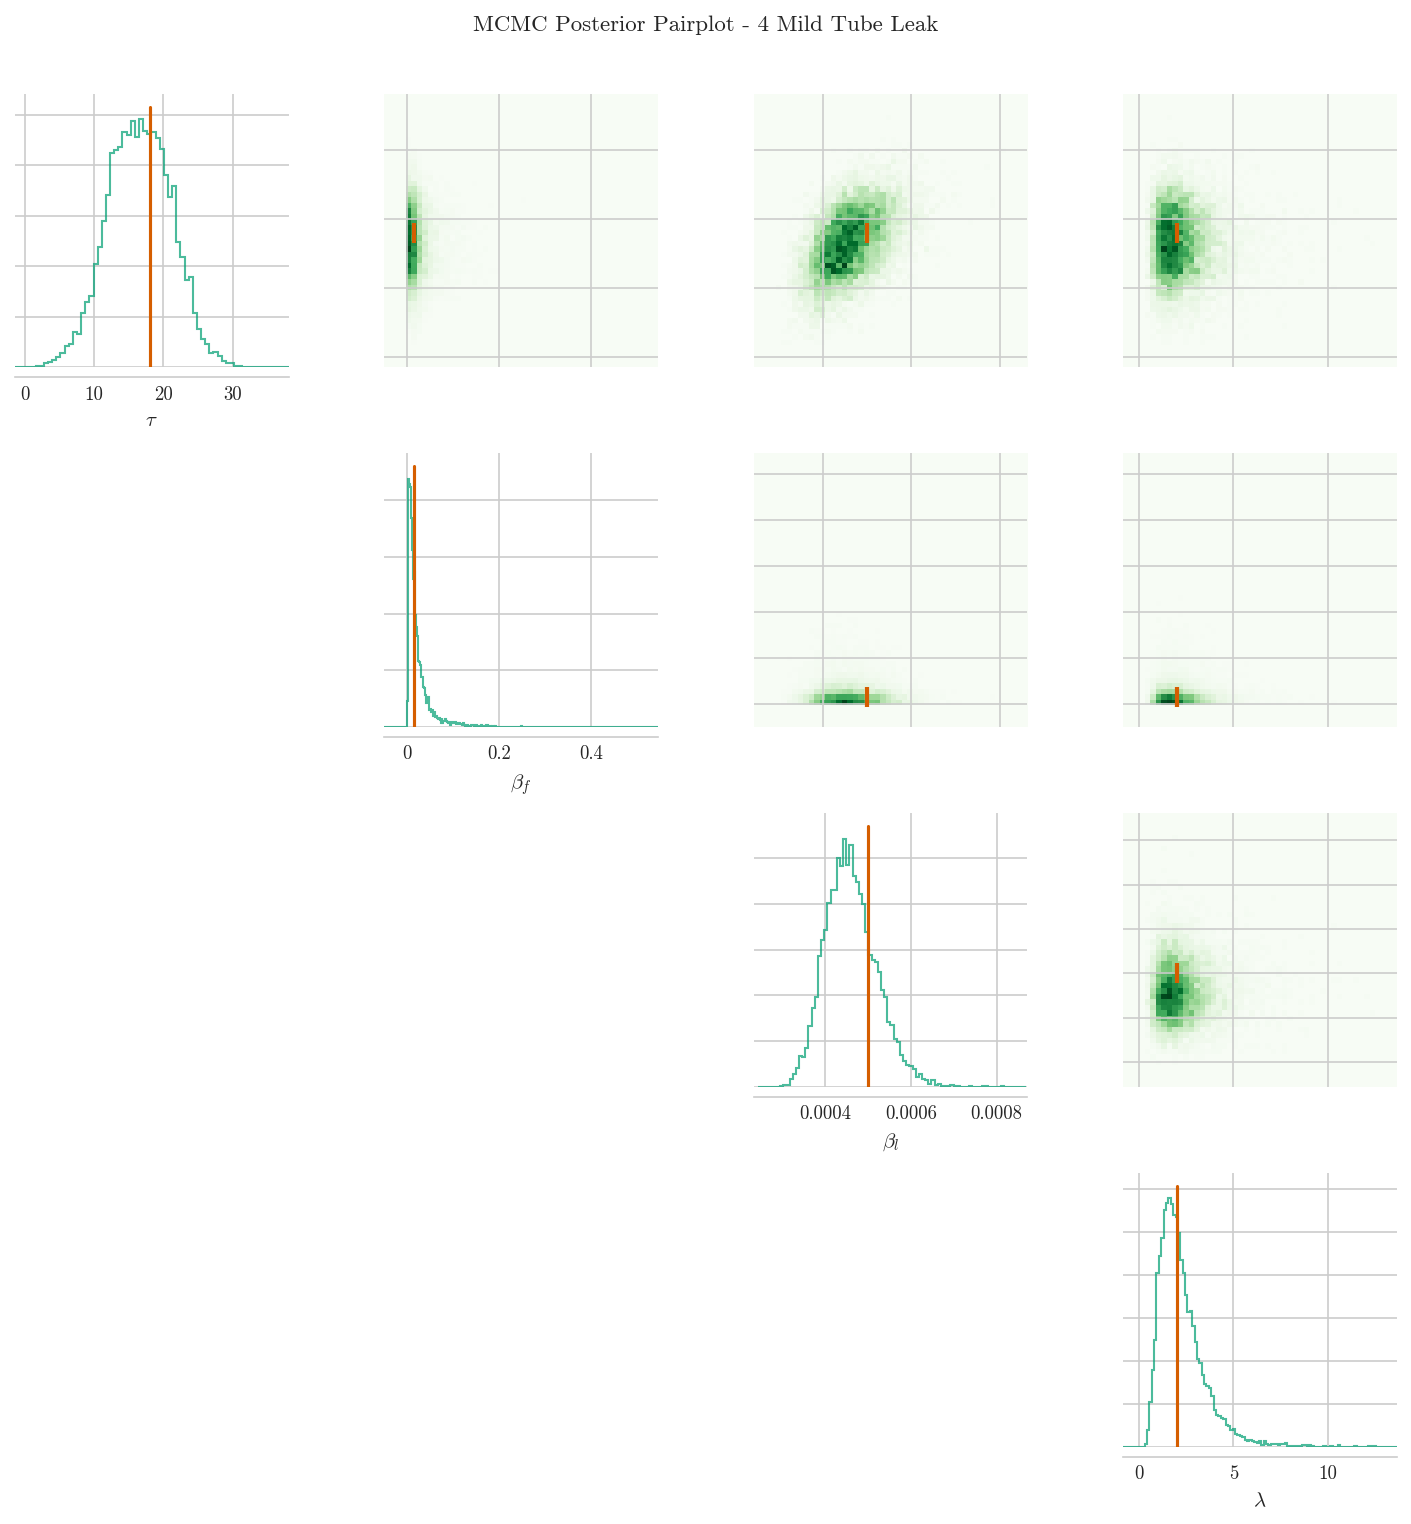

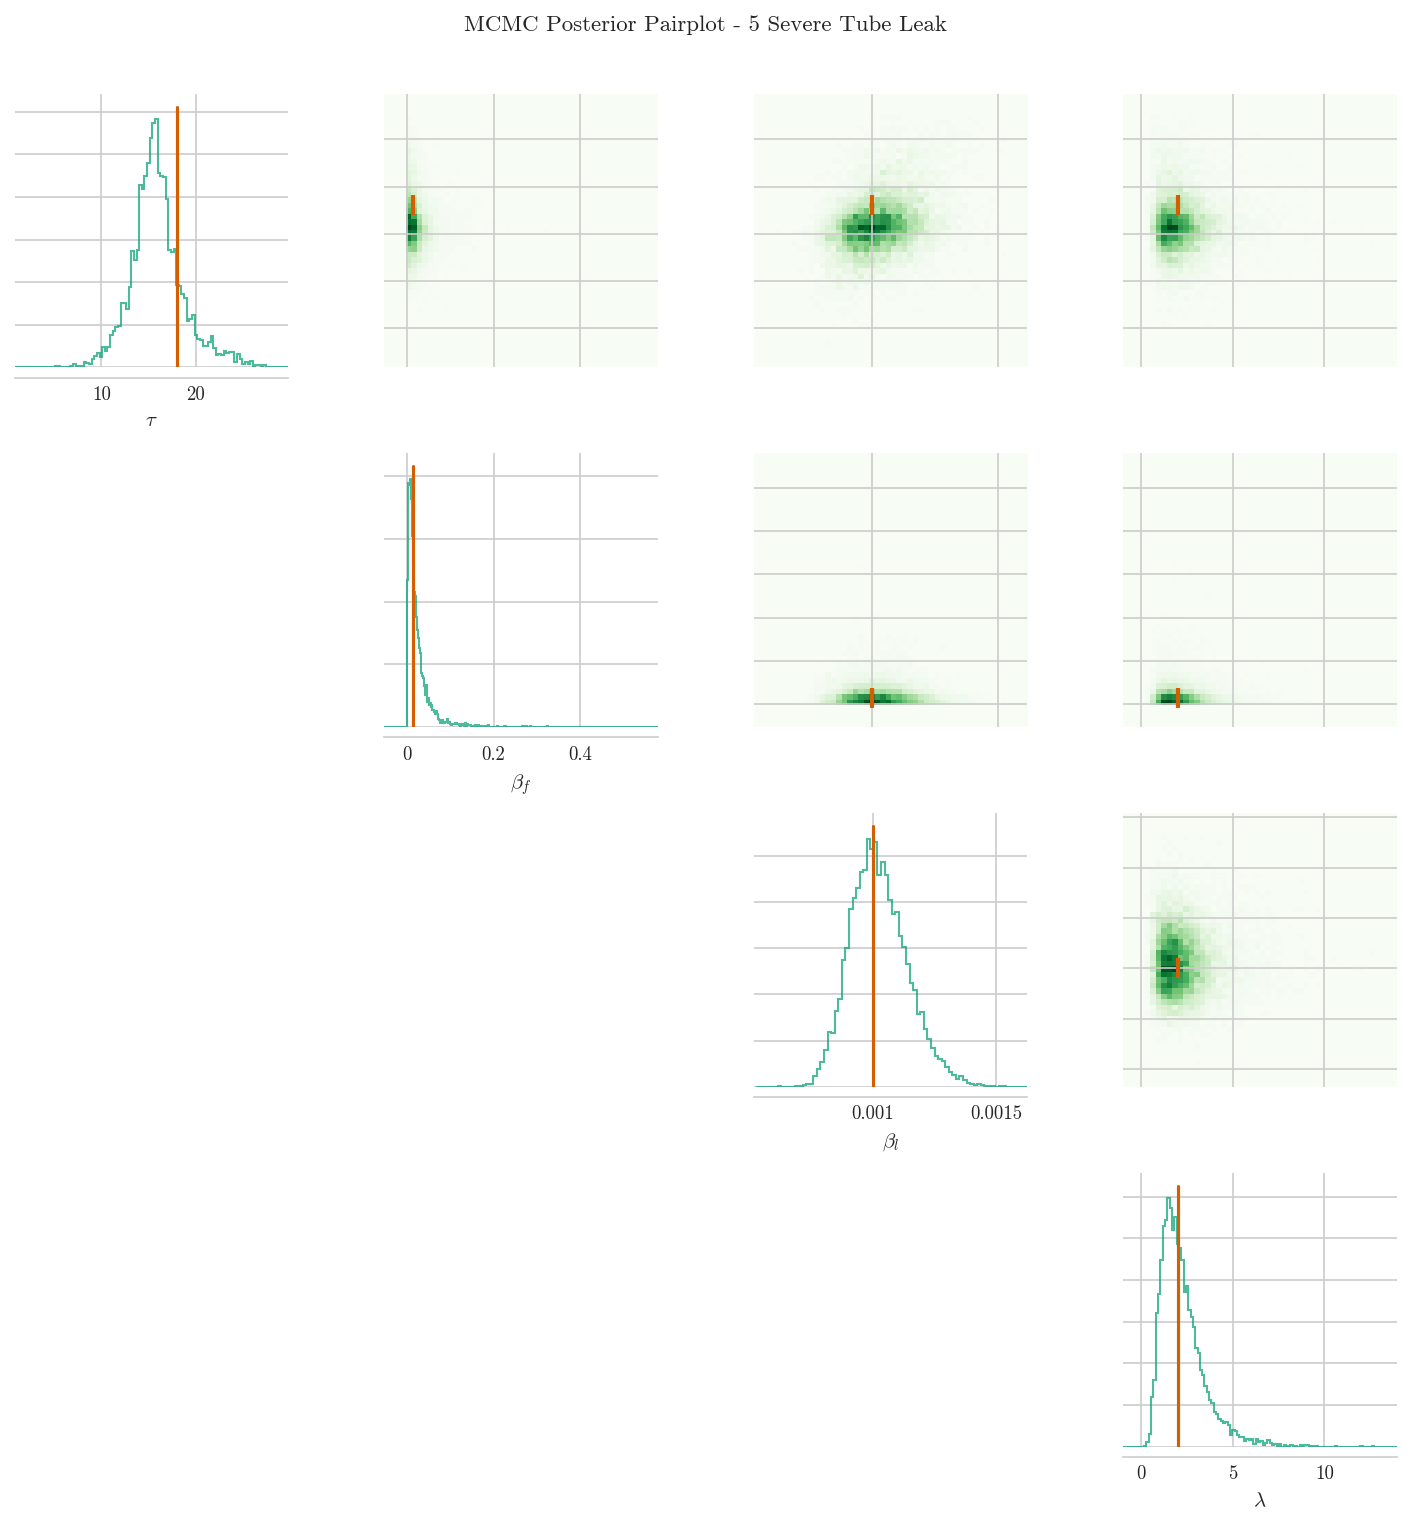

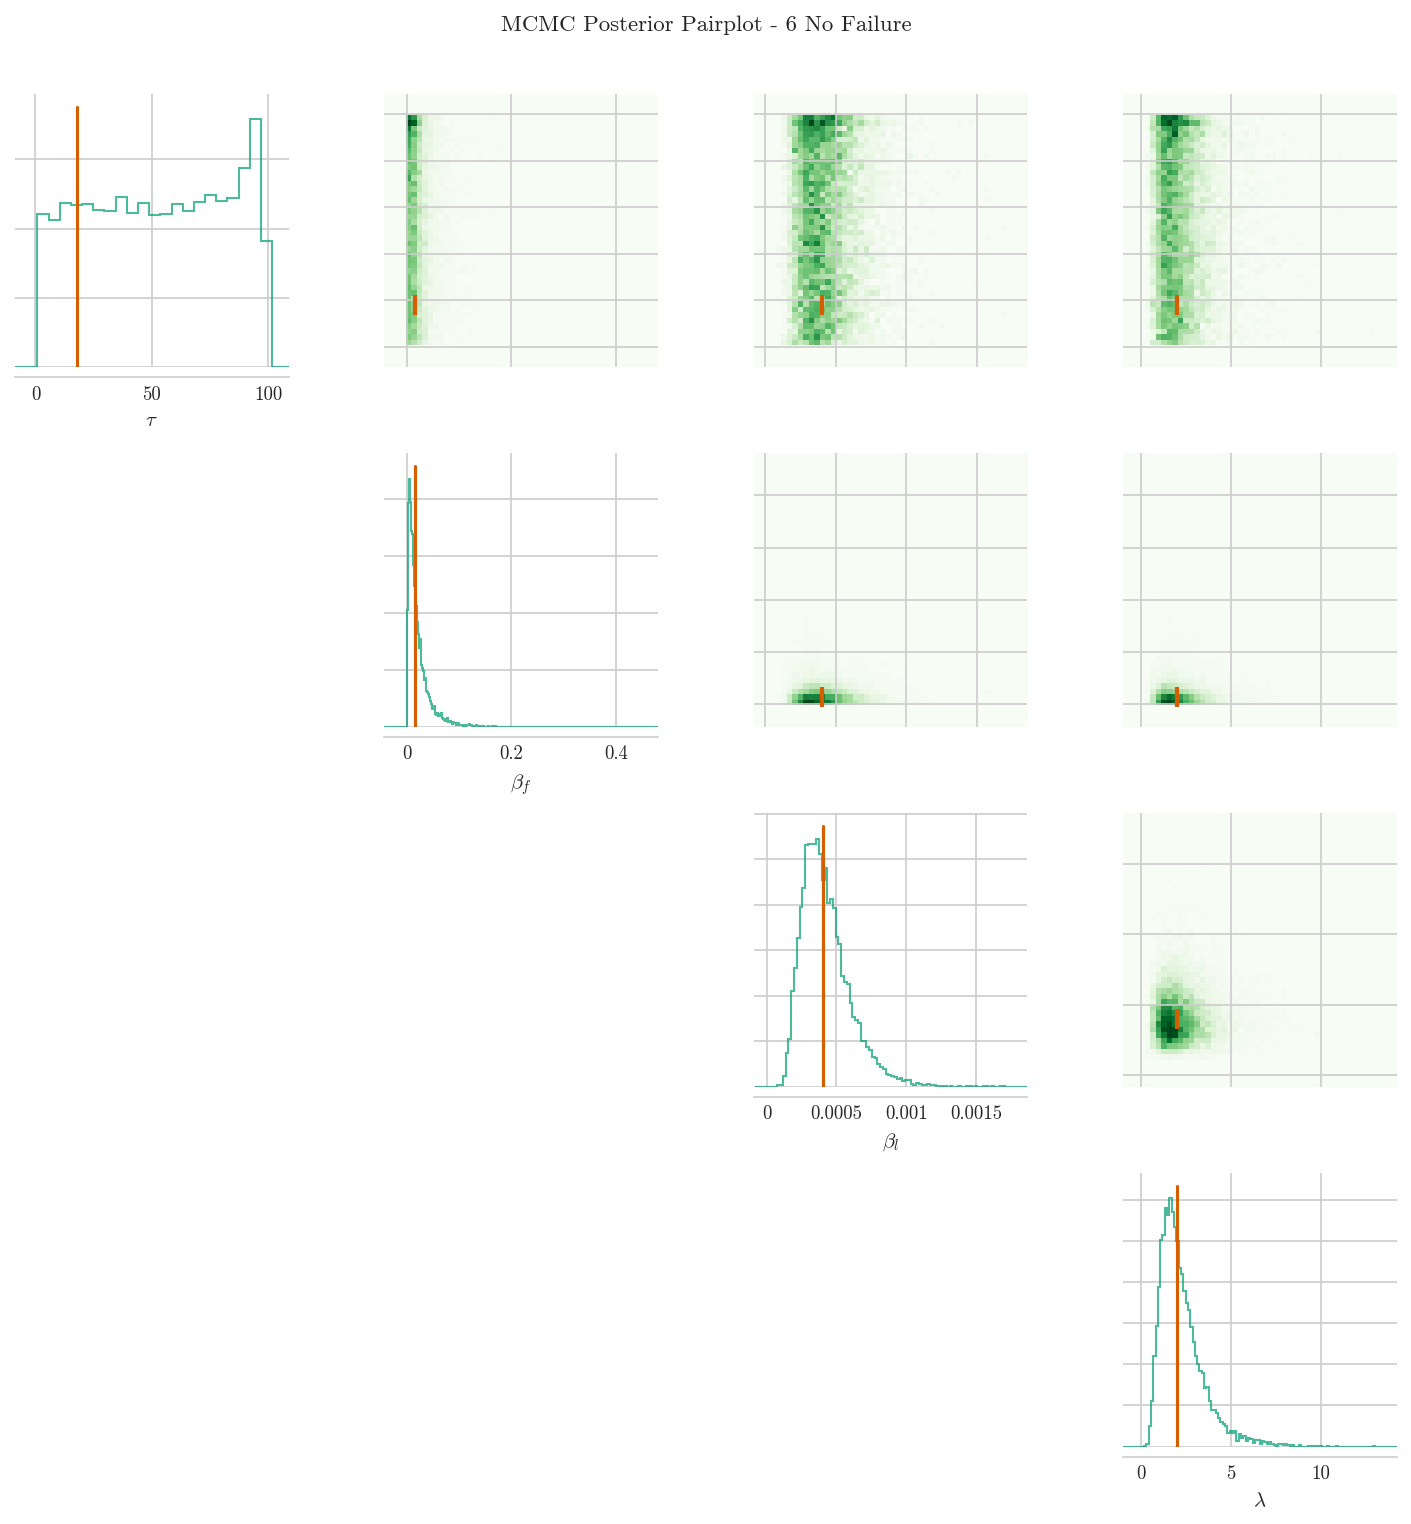

In [33]:
for scenario_name in ACTIVE_SCENARIOS:
    config = SCENARIO_CONFIGS[scenario_name]
    mcmc = mcmc_results[scenario_name]
    label = scenario_name.replace("scenario_", "").replace("_", " ").title()

    mcmc_samples = np.column_stack([
        mcmc["tau_samples"][REPEAT_IDX],
        mcmc["beta_f_samples"][REPEAT_IDX],
        mcmc["beta_l_samples"][REPEAT_IDX],
        mcmc["lambda_rate_samples"][REPEAT_IDX],
    ])

    true_point = np.array([[
        config["tau"],
        config["beta_f"],
        config["beta_l"],
        config["lambda_rate"],
    ]])
    labels_mcmc = [r"$\tau$", r"$\beta_f$", r"$\beta_l$", r"$\lambda$"]

    fig, _ = sbi_pairplot(
        torch.tensor(mcmc_samples, dtype=torch.float32),
        points=torch.tensor(true_point, dtype=torch.float32),
        labels=labels_mcmc,
        upper="hist",
        diag="hist",
        figsize=(10, 10),
        diag_kwargs={"mpl_kwargs": {"color": MCMC_COLOR, "alpha": 0.7}},
        upper_kwargs={"mpl_kwargs": {"cmap": "Greens"}},
        fig_kwargs={
            "points_colors": [TRUE_COLOR],
            "points_offdiag": {"marker": "|", "markersize": 10, "markeredgewidth": 2},
            "legend": False,
        },
    )
    fig.suptitle(f"MCMC Posterior Pairplot - {label}", y=1.01, fontsize=11)
    plt.tight_layout()
    save_fig(fig, figures_dir / f"pairplot_mcmc_{scenario_name}")
    plt.show()


## Summary

In [34]:
PARAM_DISPLAY = {"tau": "τ", "beta_f": "β_f", "beta_l": "β_l", "lambda_rate": "λ"}

rows = []
for scenario_name in ACTIVE_SCENARIOS:
    config = SCENARIO_CONFIGS[scenario_name]
    label = scenario_name.replace('scenario_', '').replace('_', ' ').title()
    metrics = all_metrics[scenario_name]
    
    mcmc_acc = np.mean([m["mcmc_z_correct"] for m in metrics])
    sbi_acc = np.mean([m["sbi_z_correct"] for m in metrics])
    
    row = {"Scenario": label, "MCMC Mode Acc.": f"{mcmc_acc:.1%}", "SBI Mode Acc.": f"{sbi_acc:.1%}"}
    
    for param_key, param_label in PARAMS:
        display = PARAM_DISPLAY.get(param_key, param_key)
        mcmc_crps_mean = np.mean([m[f"mcmc_{param_key}_crps"] for m in metrics])
        sbi_crps_mean = np.mean([m[f"sbi_{param_key}_crps"] for m in metrics])
        row[f"MCMC CRPS {display}"] = f"{mcmc_crps_mean:.4f}"
        row[f"SBI CRPS {display}"] = f"{sbi_crps_mean:.4f}"
    
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,Scenario,MCMC Mode Acc.,SBI Mode Acc.,MCMC CRPS τ,SBI CRPS τ,MCMC CRPS β_f,SBI CRPS β_f,MCMC CRPS β_l,SBI CRPS β_l,MCMC CRPS λ,SBI CRPS λ
0,1 Normal Operation,100.0%,100.0%,3.9294,4.5966,0.0009,0.0012,0.0000,0.0000,2.3130,2.3210
1,2 Batch Shutdown,100.0%,100.0%,3.5172,4.9285,0.0113,0.0129,0.0000,0.0000,0.8999,1.1509
2,3 Boiler Feedwater,100.0%,100.0%,1.1543,2.2036,0.0037,0.0044,0.0000,0.0000,0.4156,0.4707
3,4 Mild Tube Leak,99.8%,100.0%,2.2608,2.8748,0.0043,0.0047,0.0000,0.0000,0.2413,0.2469
4,5 Severe Tube Leak,99.6%,100.0%,1.6431,2.5468,0.0043,0.0053,0.0001,0.0001,0.2415,0.2592
5,6 No Failure,98.2%,97.0%,24.5403,28.0965,0.0040,0.0037,0.0000,0.0000,0.2414,0.2409
